# Lean-31 : Euler et Navier–Stokes — reproduction pinée, chaînes de preuve classées, chronologie et visualisations animées

**Navigation** : [Sommaire de la série](README.md) · [<< Précédent : Lean-30](Lean-30-FormalGroups-Native.ipynb) · [Issue #15400](https://github.com/jsboige/CoursIA/issues/15400) · [Issue #16569](https://github.com/jsboige/CoursIA/issues/16569)

Ce notebook accompagne la reproduction pinée du dépôt public [`openai/NavierStokesAndEuler`](https://github.com/openai/NavierStokesAndEuler) au commit `8937a8f4…`, toolchain `leanprover/lean4:v4.34.0-rc2`. Il poursuit trois objets distincts, qu'il ne faut jamais confondre :

1. **la vérification mécanique** — ce que le harnais [`scripts/notebook_tools/nse_reproduction.py`](../../../scripts/notebook_tools/nse_reproduction.py) mesure sur des artefacts réels : SHA du checkout, pins de dépendances, toolchain, empreintes des challenges, verdicts de deux kernels indépendants, axiomes effectivement utilisés, hygiène des `sorry` et des `native_decide`, postcondition d'orphelins ;
2. **l'exposition mathématique** — la chaîne de preuve qui relie les maillons d'Euler d'une part, et les deux adaptateurs d'option (C) et (D) de Navier–Stokes d'autre part, avec la **classe** de chaque maillon ;
3. **le contexte et l'image** — la chronologie de la semaine du 7 au 14 septembre 2026 (le « drama » qui a accompagné l'annonce), puis une lecture visuelle animée de l'écoulement, inspirée de l'exploration intuitive de [Jayanta Phadikar sur Wolfram Community](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013), poussée plus loin : échelle continue de couleurs par scalaire, vecteurs de taille variable.

La leçon centrale du notebook tient en une phrase : *un kernel qui accepte un artefact ne dit rien de la valeur de l'exposition qui l'accompagne, et une exposition convaincante ne dit rien de l'acceptation mécanique.* Les deux sont nécessaires et aucune ne remplace l'autre. La semaine de septembre 2026 en a fourni l'illustration la plus spectaculaire, et la plus disputée.

> **Ce que ce notebook n'est pas** : ni un vendor du dépôt amont (aucun sous-arbre n'est copié), ni un verdict sur un problème ouvert, ni un récit d'autorité. Il rapporte qu'un artefact identifié par une empreinte a été accepté par deux noyaux en n'utilisant que des axiomes permis, il classe les maillons d'une chaîne de preuve, et il **reconstruit** un écoulement à titre didactique — il n'affirme **à aucun moment** que le problème du millénaire sur Navier–Stokes serait résolu — voir la section 6, qui énonce explicitement ce que le rapport **ne** permet **pas** de conclure, et la section 8, qui énonce ce que la communauté elle-même en a dit.


## Objectifs, prérequis et durée

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. distinguer **vérification mécanique** (un artefact accepté par deux noyaux) et **exposition mathématique** (pourquoi la conclusion s'ensuit) ;
2. énoncer la **chaîne de reproduction Euler** et la relier au critère de Beale–Kato–Majda (BKM) sur la vorticité ;
3. énoncer les **deux options du Comparator Navier–Stokes** — option (C) sur ℝ³ et option (D) sur ℝ³/ℤ³ — et la **construction de candidat partagée** qu'elles consomment l'une et l'autre ;
4. **classer** un maillon dans l'une des cinq classes du protocole : `upstream`, `local`, `proved`, `bridged`, `packaged` ;
5. **re-dériver** le verdict d'un rapport de vérification à partir de ses feuilles, au lieu de faire confiance au champ de synthèse `all_verified` ;
6. délimiter ce qu'un tel rapport **ne** prouve **pas** ;
7. **dérouler la chronologie** de la semaine du 7 au 14 septembre 2026 — annonces, contre-publication, déclaration des médaillés Fields — et y situer la position de ce dépôt ;
8. **lire visuellement** un écoulement auto-similaire vers la rupture : vorticité en échelle continue, vecteurs de taille variable, profils radiaux — et savoir dire ce qu'une reconstruction qualitative ne certifie **pas**.

### Prérequis

- Python 3.10+ (`json`, `re`, `subprocess`, `pathlib`, `numpy`, `matplotlib`, `PIL`) ;
- notions de Lean 4 : théorème, `#print axioms`, noyau de vérification ;
- les bases du critère BKM : équation d'Euler incompressible en dimension 3, vorticité `ω = curl u`.

### Durée estimée : 60 minutes

> **Note de méthode** — Les maillons classés ici sont **lus dans la source pinnée** : chaque entrée des chaînes porte le nom exact de sa déclaration Lean et le fichier qui la porte. La classification n'est pas une conjecture sur des noms rapportés, c'est une caractérisation d'un `def`, d'une `structure`, d'un `theorem` ou d'un pont de vocabulaire. Les déclarations citées proviennent en particulier de `Euler/Solution.lean`, `Euler/InitialDataBridge.lean`, `Euler/PacketFiniteLifespan.lean`, `Euler/OrdinaryEulerBKM.lean`, `Euler/OrdinaryLogarithmicGradient.lean`, `Euler/EulerSingularity.lean`, `Euler/ComparatorEvolutionIdentification.lean`, `Euler/ComparatorLocalEvolution.lean`, `Euler/ComparatorIdentification.lean`, `Euler/CompactVorticityContradiction.lean`, `Euler/CanonicalVorticityConfinement.lean`, `NavierStokes/ProblemStatement.lean`, `NavierStokes/R3CompactCandidate.lean`, `NavierStokes/R3ActualCandidate.lean`, `NavierStokes/ActualCandidateAssembly.lean`, `NavierStokes/R3FiniteEnergyComparison.lean`, `NavierStokes/MaximalLifespan.lean`, `NavierStokes/ComparatorR3Theorem.lean`, `NavierStokes/ComparatorTheorem.lean` et `NavierStokes/ComparatorSolution.lean`.


## Plan

1. [Le gate de reproduction](#1-le-gate-de-reproduction) — vérification mécanique *vs* exposition
2. [La chaîne Euler et le critère BKM](#2-la-chaîne-euler-et-le-critère-bkm)
3. [Construction partagée, option (C), option (D)](#3-construction-partagée-option-c-option-d)
4. [Classer les maillons](#4-classer-les-maillons) — cinq classes
5. [Re-dériver le verdict depuis les feuilles](#5-re-dériver-le-verdict-depuis-les-feuilles)
6. [Portée, limites et non-claims](#6-portée-limites-et-non-claims)
7. [Exercices](#7-exercices)
8. [Septembre 2026 — la course Navier–Stokes et son arbitrage](#8-septembre-2026--la-course-navierstokes-et-son-arbitrage) — chronologie et drama
9. [Lire l'écoulement : reconstruire le mécanisme pour l'œil](#9-lire-lécoulement-reconstruire-le-mécanisme-pour-lœil) — GIFs animés
10. [Conclusion](#conclusion)


## 1. Le gate de reproduction

Avant de parler de preuve, il faut savoir ce qui a été **mesuré**. Le pilote #15400 est encadré par un *gate de reproduction* : deux commandes Comparator exécutées séparément (Euler, puis Navier–Stokes), chacune devant rendre un verdict sans ambiguïté, avec les mêmes pins conservés avant et après. Tant que ce gate n'est pas franchi, aucune digestion n'est déclarée — c'est la règle que l'issue énonce en toutes lettres.

Le harnais `nse_reproduction.py` existe pour rendre ce gate **falsifiable** plutôt que déclaratif. Il n'imprime pas un « succès » : il imprime un agrégat de faits vérifiables, chacun pouvant être faux indépendamment des autres. **Les deux gates sont verts** : les deux challenges sont acceptés par les deux kernels, sous les seuls axiomes permis.

### 1.1 Trois notions à ne pas confondre

| Notion | Question à laquelle elle répond | Où elle vit | Ce qu'elle ne dit pas |
|---|---|---|---|
| **Preuve mathématique** | *pourquoi* la conclusion s'ensuit-elle ? | l'exposition (§2, §3) | rien sur l'exécution réelle d'un binaire |
| **Vérification mécanique** | ce noyau accepte-t-il *cet* artefact ? | le harnais (`check`) | rien sur la justesse de l'idée, ni sur la nouveauté du résultat |
| **Reproduction** | puis-je reconstruire le même artefact ? | pins : SHA, toolchain, pins de dépendances, empreintes | rien sur le sens de l'énoncé reproduit |

Le point décisif est le suivant : la vérification mécanique est une affirmation **sur un fichier**, pas sur les mathématiques. Elle dit — au mieux — « cet artefact précis, identifié par son empreinte, a été accepté par deux implémentations indépendantes du noyau, en n'utilisant que les axiomes permis ». Elle ne dit pas que l'exposition est convaincante, ni qu'un lecteur humain la suivrait, ni que l'énoncé est intéressant.

Symétriquement, une exposition lumineuse ne dit rien de l'exécution : elle peut décrire une chaîne que le code n'établit pas. **Un notebook honnête doit tenir les deux séparés, et c'est ce que fait celui-ci.**

### 1.2 Le contrat de preuve du harnais

La cellule suivante établit le **cadre d'exécution** : elle localise le dépôt en remontant l'arborescence (aucun chemin absolu n'est écrit dans la source), transcrit les **constantes du contrat** telles que le harnais les déclare, et définit un caviardage de tout chemin qui remonterait d'un diagnostic. Elle produit un état de configuration, pas un résultat.

In [1]:
# Code 1.1 - Cadre d'execution : contrat du harnais et resolution du rapport
#
# Aucune sortie n'est fabriquee : ce notebook consomme le rapport JSON du harnais
# scripts/notebook_tools/nse_reproduction.py. Sources, dans cet ordre :
#   1. la variable d'environnement NSE_REPORT_JSON (rapport capture ailleurs) ;
#   2. un fichier nse_report.json a cote du notebook ou a la racine du depot ;
#   3. l'execution du harnais (sous-commande `check`), qui relit via WSL les
#      artefacts d'audit produits sur l'hote d'execution des Comparators.
#
# Ce rapport est une ENTREE REQUISE : la cellule 1.2 echoue explicitement s'il est
# introuvable (voir sa documentation). Un notebook publie ne degrade pas en silence
# une mesure de securite en un affichage vide.
#
# Aucun chemin prive de machine n'est ecrit ici : le depot est localise en remontant
# l'arborescence, et tout chemin absolu remonte d'un diagnostic est caviarde.
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from pathlib import Path

SCRIPT_REL = Path("scripts") / "notebook_tools" / "nse_reproduction.py"


def find_repo_root(start=None):
    """Remonte l'arborescence jusqu'au depot qui porte le harnais."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / SCRIPT_REL).is_file():
            return candidate
    return None


_PRIVATE_PATH_RE = re.compile(
    r"/(?:home|Users|root|mnt|tmp|opt|var|srv|usr/local)/[^\s'\"]+"
    r"|[A-Za-z]:[\\/][^\s'\"]+"
)


def sanitize(text):
    """Remplace tout chemin absolu (POSIX ou Windows) par un jeton neutre.

    Le harnais nomme le checkout amont dans ses diagnostics ; on ne veut de chemin
    prive de machine ni dans la source, ni dans les sorties committeees.
    """
    return _PRIVATE_PATH_RE.sub("<chemin-local>", str(text))


REPO_ROOT = find_repo_root()
SCRIPT = (REPO_ROOT / SCRIPT_REL) if REPO_ROOT is not None else None

# --- Contrat de verification, transcrit du harnais (source unique) -------------
PINNED_SHA = "8937a8f4cbc7abaab5e9e97d1cc7f5d2319d9538"
TOOLCHAIN = "leanprover/lean4:v4.34.0-rc2"
NANODA_LIB_SHA = "68d5ca9db226849b41a6fff59d796ff19d0a8840"
DEPENDENCY_PINS = {
    "Comparator": "19e111e2141cf333c7daff0f64c5f24acc91dd2e",
    "mathlib": "85e3a25e006c35636f0e53b0e9296caca2685bc0",
    "lean4export": "cacf989bd75f608700820f6afc595f32e7a99a4d",
}
PERMITTED_AXIOMS = ("Classical.choice", "Quot.sound", "propext")
EXPECTED_AXIOM_DECLARATIONS = (
    "Euler.euler_breakdown_R3",
    "Euler.exists_compact_smooth_euler_singularity",
    "EulerPacketInduction.exists_compact_smooth_euler_singularity",
    "EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_unbounded",
    "EulerOrdinarySobolev.logarithmic_gradient_bound_solenoidal",
    "NavierStokes.Comparator.navier_stokes_breakdown_R3",
    "NavierStokes.Comparator.navier_stokes_breakdown_periodic",
    "NavierStokes.ComparatorBridge.option_C_of_compact_candidate",
    "NavierStokes.ComparatorBridge.option_D_of_candidate",
    "NavierStokes.ComparatorBridge.compact_candidate_excludes_global_solution",
    "NavierStokes.MaximalLifespan.candidate_excludes_global_solution",
)
EXPECTED_CHALLENGE_SHA256 = {
    "euler": "56bc185a931f68d9a0f0265a3c00cb12771dccc85384eaf6546b37844b8adc84",
    "navier_stokes": "7610ecead7b390d80ff7f4229a3ff8f18d630e046f7ad1de4f92c7e8e76845b8",
}
CHALLENGE_SOLUTION_MODULES = {
    "euler": "Euler.Solution",
    "navier_stokes": "NavierStokes.ComparatorSolution",
}

# --- Classes du protocole de classification (enumeration FERMEE) --------------
CLASS_ENUM = ("upstream", "local", "proved", "bridged", "packaged")
CLASS_COLORS = {
    "upstream": "#6b7f8f",
    "local": "#c9a227",
    "proved": "#2e7d4f",
    "bridged": "#8a5cc4",
    "packaged": "#b3402a",
}


def draw_chain(ax, chain, title):
    """Empile les maillons du haut vers le bas ; les fleches vont vers la conclusion."""
    import matplotlib.pyplot as plt

    height = len(chain)
    for position, (name, classe, _decl, _file) in enumerate(chain):
        y = height - position
        colour = CLASS_COLORS.get(classe, "#444444")
        ax.add_patch(plt.Rectangle((0.05, y - 0.34), 0.90, 0.68, facecolor=colour,
                                   alpha=0.14, edgecolor=colour, linewidth=1.4))
        ax.text(0.09, y, name, fontsize=8.4, va="center", family="monospace")
        ax.text(0.93, y, classe, fontsize=8.4, va="center", ha="right",
                color=colour, fontweight="bold")
        if position:
            ax.annotate("", xy=(0.5, y + 0.34), xytext=(0.5, y + 0.66),
                        arrowprops=dict(arrowstyle="-|>", color="#444444", lw=1.1))
    ax.set_xlim(0, 1)
    ax.set_ylim(0.4, height + 0.7)
    ax.axis("off")
    ax.set_title(title, fontsize=10)


print(f"Depot localise        : {REPO_ROOT.name if REPO_ROOT is not None else 'INTROUVABLE'}")
print(f"Harnais               : {SCRIPT_REL.as_posix()} "
      f"({'present' if SCRIPT is not None else 'ABSENT'})")
print(f"Python                : {sys.version.split()[0]}")
print(f"Pin declare           : {PINNED_SHA}")
print(f"Toolchain declaree    : {TOOLCHAIN}")
print(f"Pins de dependances   : {len(DEPENDENCY_PINS)} entrees")
print(f"Kernel alternatif     : nanoda {NANODA_LIB_SHA}")
print(f"Axiomes permis        : {', '.join(sorted(PERMITTED_AXIOMS))}")
print(f"Challenges du contrat : {', '.join(sorted(EXPECTED_CHALLENGE_SHA256))}")
print(f"Cibles d'axiomes      : {len(EXPECTED_AXIOM_DECLARATIONS)} declarations sondees")
print(f"Modules Solution      : {', '.join(f'{k}={v}' for k, v in sorted(CHALLENGE_SOLUTION_MODULES.items()))}")
print(f"Classes du protocole  : {', '.join(CLASS_ENUM)}")

Depot localise        : CoursIA-16569-lean31-gifs
Harnais               : scripts/notebook_tools/nse_reproduction.py (present)
Python                : 3.13.15
Pin declare           : 8937a8f4cbc7abaab5e9e97d1cc7f5d2319d9538
Toolchain declaree    : leanprover/lean4:v4.34.0-rc2
Pins de dependances   : 3 entrees
Kernel alternatif     : nanoda 68d5ca9db226849b41a6fff59d796ff19d0a8840
Axiomes permis        : Classical.choice, Quot.sound, propext
Challenges du contrat : euler, navier_stokes
Cibles d'axiomes      : 11 declarations sondees
Modules Solution      : euler=Euler.Solution, navier_stokes=NavierStokes.ComparatorSolution
Classes du protocole  : upstream, local, proved, bridged, packaged


### Lecture du résultat — un état de configuration, pas un résultat : les constantes du contrat transcrites pour être contredites

La cellule a produit un **état de configuration**, et rien d'autre : elle ne prétend pas avoir vérifié quoi que ce soit. Trois éléments méritent d'être relevés :

| Élément affiché | Ce qu'il établit | Ce qu'il n'établit pas |
|---|---|---|
| Le nom du dépôt localisé | le harnais est retrouvable depuis le dossier courant, ou ne l'est pas | que le checkout amont existe sur cette machine |
| La présence du harnais (`present` / `ABSENT`) | la cellule 1.2 saura s'il faut tenter une exécution | que cette exécution réussira |
| Les constantes du contrat transcrites | les valeurs **attendues** (pin, dépendances, toolchain, axiomes, empreintes) | que le checkout observé les atteint |

**Pourquoi transcrire les constantes plutôt que les lire du harnais ?** Parce qu'un vérificateur qui importerait ses valeurs attendues de l'objet qu'il vérifie ne vérifierait rien. La transcription est ici un acte de **contrôle croisé** : si le harnais change ses pins, la cellule 5.1 le rendra visible par désaccord, au lieu de suivre silencieusement.

Le `pinned_sha` est affiché **en entier** : il est ensuite comparé au `observed_sha` par la re-dérivation, et une comparaison de tronçons masquerait précisément le désaccord qu'on cherche à voir.

> **Note technique** : le caviardage (`sanitize`) s'applique à des *chaînes de diagnostic*. Il ne réécrit jamais une sortie de cellule : c'est la source qui ne doit pas laisser fuir un chemin d'installation dans un notebook publié.

### 1.3 Chargement du rapport

Le rapport du harnais est un dictionnaire dont les champs se répartissent en cinq familles : **identité** (pin observé, toolchain, pins de dépendances observés, rev du noyau nanoda), **confinement** (version de `landrun` et probe fonctionnel), **hygiène logique** (probes d'axiomes, axiomes interdits, compteurs `sorry` et `native_decide`, sous-objet `integrity`), **verdicts par challenge** (un enregistrement `gate` par challenge), et un **champ de synthèse** `all_verified`.

Ce rapport est une **entrée requise**, pas une commodité. La cellule suivante lève une exception explicite si aucune source n'en fournit un, plutôt que de poursuivre avec des mesures absentes :

- un notebook qui remplacerait une vérification disponible par une valeur vide laisserait croire qu'un gate a été franchi sans qu'on puisse le montrer ;
- le corollaire est assumé : **ce notebook ne s'exécute que là où le rapport existe**. C'est une propriété, pas une limite — rejouer les exécutions Comparator demande un hôte portant Landlock, et refuser de tourner ailleurs est exactement la discipline que l'issue #15400 impose au gate de reproduction.

In [2]:
# Code 1.2 - Chargement du rapport : variable d'environnement, fichier local, harnais
#
# Le rapport est une ENTREE REQUISE. En son absence, la cellule leve une exception :
# elle n'affiche pas de valeurs de remplacement. Un gate de securite ne se degrade pas
# en un affichage vide -- il refuse de conclure.
import json
import os
import subprocess
import sys
from pathlib import Path


class RapportIntrouvable(RuntimeError):
    """Le rapport du harnais n'est disponible par aucune des trois sources."""


def read_report_json(path):
    """Parse un fichier de rapport ; leve si la lecture ou le parsing echoue."""
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        raise RapportIntrouvable(
            f"{sanitize(path)} : lecture impossible ({type(exc).__name__})") from exc


def load_report():
    """Retourne (rapport, source). Leve RapportIntrouvable si aucune source ne repond."""
    env_path = os.environ.get("NSE_REPORT_JSON")
    candidates = []
    if env_path:
        candidates.append(("variable NSE_REPORT_JSON", Path(env_path)))
    bases = [Path.cwd()]
    if REPO_ROOT is not None:
        bases.append(REPO_ROOT)
    for base in bases:
        candidates.append((f"fichier local ({base.name})", base / "nse_report.json"))

    for label, path in candidates:
        if path.is_file():
            return read_report_json(path), label

    if SCRIPT is None:
        raise RapportIntrouvable(
            "harnais introuvable depuis le dossier courant, et aucun rapport "
            "nse_report.json sur le disque")

    try:
        proc = subprocess.run(
            [sys.executable, str(SCRIPT), "check"],
            capture_output=True, text=True, encoding="utf-8", errors="replace",
            timeout=900,
        )
    except (OSError, subprocess.TimeoutExpired) as exc:
        raise RapportIntrouvable(
            f"execution du harnais impossible ({type(exc).__name__})") from exc

    try:
        payload = json.loads(proc.stdout)
    except json.JSONDecodeError as exc:
        raise RapportIntrouvable(
            f"sortie du harnais non-JSON (code retour {proc.returncode})") from exc

    if "error" in payload:
        raise RapportIntrouvable(sanitize(payload["error"]))
    return payload, "execution du harnais"


def field(report, key, default="<absent>"):
    """Lecture defensive : champ absent et champ None rendent le meme jeton."""
    if not isinstance(report, dict):
        return default
    value = report.get(key, default)
    return default if value is None else value


REPORT, REPORT_SOURCE = load_report()
GATES = {name: gate for name, gate in (REPORT.get("gates") or {}).items()
         if isinstance(gate, dict)}
INTEGRITY = REPORT.get("integrity") if isinstance(REPORT.get("integrity"), dict) else {}
CONFINEMENT = REPORT.get("confinement") if isinstance(REPORT.get("confinement"), dict) else {}

print(f"Source du rapport     : {REPORT_SOURCE}")
print(f"  pin observee          : {field(REPORT, 'observed_sha')}")
print(f"  concordance du pin    : {field(REPORT, 'sha_matches_pin')}")
print(f"  toolchain             : {field(REPORT, 'toolchain')}")
print(f"  concordance toolchain : {field(REPORT, 'toolchain_matches')}")
print(f"  pins de dependances   : {field(REPORT, 'dependency_pins_match')}")
print(f"  nanoda (rev)          : {field(REPORT, 'nanoda_lib_sha')}")
print(f"  confinement           : {field(CONFINEMENT, 'engine')} / "
      f"{field(CONFINEMENT, 'version')} / verifie={field(CONFINEMENT, 'verified')}")
print(f"    ecriture interdite refusee : {field(CONFINEMENT, 'unauthorized_write_denied')}")
print(f"    ecriture autorisee reussie : {field(CONFINEMENT, 'authorized_write_allowed')}")
print(f"  probes d'axiomes      : {field(REPORT, 'axiom_probe_count')}")
AXIOM_DECLS = REPORT.get("axiom_declarations")
if isinstance(AXIOM_DECLS, list) and AXIOM_DECLS:
    print(f"  declarations sondees  : {len(AXIOM_DECLS)} (preuves nommees)")
    for declaration in AXIOM_DECLS:
        print(f"    - {declaration}")
else:
    print(f"  declarations sondees  : {field(REPORT, 'axiom_declarations')}")
print(f"  axiomes permis        : {field(REPORT, 'permitted_axioms')}")
print(f"  axiomes interdits     : {field(REPORT, 'forbidden_axioms')}")
print(f"  sans axiome interdit  : {field(REPORT, 'axioms_within_permitted')}")
print(f"  sorry / native_decide : {field(REPORT, 'sorry_proof_count')} / "
      f"{field(REPORT, 'native_decide_count')}")
print(f"  integrite verifiee    : {field(INTEGRITY, 'verified')}")
print(f"  signatures challenges : {len(INTEGRITY.get('challenge_sorry_locations', []))}")
for name, gate in sorted(GATES.items()):
    print(f"  gate {name:14s} : verifie={gate.get('verified')} "
          f"kernels={gate.get('kernels')} "
          f"empreinte={gate.get('challenge_hash_matches')} "
          f"verdict={gate.get('semantic_verdict')}")
print(f"  all_verified (declare): {field(REPORT, 'all_verified')}")

Source du rapport     : variable NSE_REPORT_JSON
  pin observee          : 8937a8f4cbc7abaab5e9e97d1cc7f5d2319d9538
  concordance du pin    : True
  toolchain             : leanprover/lean4:v4.34.0-rc2
  concordance toolchain : True
  pins de dependances   : True
  nanoda (rev)          : 68d5ca9db226849b41a6fff59d796ff19d0a8840
  confinement           : landrun / landrun version 0.1.17 / verifie=True
    ecriture interdite refusee : True
    ecriture autorisee reussie : True
  probes d'axiomes      : 11
  declarations sondees  : 11 (preuves nommees)
    - Euler.euler_breakdown_R3
    - Euler.exists_compact_smooth_euler_singularity
    - EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_unbounded
    - EulerOrdinarySobolev.logarithmic_gradient_bound_solenoidal
    - EulerPacketInduction.exists_compact_smooth_euler_singularity
    - NavierStokes.Comparator.navier_stokes_breakdown_R3
    - NavierStokes.Comparator.navier_stokes_breakdown_periodic
    - NavierStokes.ComparatorBridge.co

### Lecture du résultat — le contrat effectif de cette exécution, et les deux champs qu'une re-dérivation oublie facilement

Le bloc affiché est le **contrat effectif** de cette exécution : le pin observé, la toolchain effective, la concordance des pins de dépendances, les probes d'axiomes, l'hygiène `sorry` / `native_decide`, l'objet `integrity`, et pour chaque challenge la conjonction `verifie` avec les deux kernels, la concordance d'empreinte et le verdict sémantique. Ce sont ces valeurs — et non celles transcrites en 1.2 — qui portent l'évidence.

Deux champs méritent une attention particulière, parce qu'ils sont **faciles à oublier dans une re-dérivation** et parce que le harnais les compte dans sa conjonction :

| Champ | Ce qu'il couvre |
|---|---|
| `dependency_pins_match` | les trois revs de dépendances (`Comparator`, `mathlib`, `lean4export`) **et** le rev du noyau nanoda. Sans lui, un checkout au bon SHA mais sur des dépendances flottantes passerait pour reproductible |
| `integrity.verified` | le recensement externe des sources suivies par git : nombre de fichiers Lean suivis, `root_sha`, `sorry` de solution, `native_decide` **et** cohérence de complétude du relevé |

> **Erreur à éviter** : lire les gates seuls. Un rapport dont les deux gates sont verts mais dont `dependency_pins_match` est faux décrit une reproduction qui n'en est pas une — les dépendances qui ont servi à accepter le challenge ne sont plus celles déclarées.

## 2. La chaîne Euler et le critère BKM

### 2.1 Le critère BKM, énoncé et portée

Pour l'équation d'Euler incompressible en dimension 3, soit `u` une solution lisse sur `[0, T*)`, de vorticité `ω = curl u`. Le critère de **Beale–Kato–Majda** (1984) énonce que la durée de vie maximale `T*` est finie **si et seulement si** l'intégrale de la norme `L∞` de la vorticité diverge :

$$
T^{*} < \infty \quad \Longleftrightarrow \quad \int_{0}^{T^{*}} \lVert \omega(t) \rVert_{L^{\infty}} \, dt = +\infty .
$$

Autrement dit : tant que `‖ω‖_{L∞}` reste intégrable en temps, la régularité se prolonge. La **conséquence opératoire** est le sens le plus souvent utilisé : pour produire une rupture en temps fini, il **suffit** d'exhiber une solution dont la vorticité explose plus vite qu'intégrablement.

Le dépôt pinné porte les deux moitiés du critère, et il les porte **prouvées**, sous des noms qu'on peut citer :

| Déclaration | Fichier | Ce qu'elle énonce |
|---|---|---|
| `EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_unbounded` | `Euler/OrdinaryEulerBKM.lean` | pour toute borne finie `G`, il existe un temps court où l'intégrale partielle de vorticité dépasse `G` |
| `EulerOrdinarySobolev.FiniteLifespan.vorticityIntegral_tendsto_atTop` | `Euler/OrdinaryEulerBKM.lean` | l'intégrale partielle tend vers `+∞` quand le temps approche la durée maximale |
| `EulerOrdinarySobolev.FiniteLifespan.vorticity_lintegral_eq_top` | `Euler/OrdinaryEulerBKM.lean` | l'intégrale étendue du suprême de vorticité vaut `⊤` sur `Ico 0 L.duration` |
| `EulerOrdinarySobolev.logarithmic_gradient_bound_solenoidal` | `Euler/OrdinaryLogarithmicGradient.lean` | l'estimation de gradient logarithmique de BKM, avec **toutes** ses hypothèses d'échelle déchargées |

L'estimation logarithmique est celle qui rend le critère utilisable : `logarithmic_gradient_bound_solenoidal` produit une borne du type `‖fderiv u x‖ ≤ C·(1 + ‖u‖ + W·log(exp 1 + ‖u‖_{H³}))` où `W` majore la vorticité — et le module porte en tête : *« No spatial estimate or unboundedness assumption remains in these conclusions »* (aucune estimation spatiale ni hypothèse de non-bornitude ne subsiste dans ces conclusions).

### 2.2 Les maillons, lus dans la source pinnée

La chaîne ci-dessous n'est pas une reconstruction : c'est la chaîne d'appel de `Euler/Solution.lean`, où `initialDatum_no_global_solution` se lit

```
exact finiteLifespan_contradiction_of_compact_vorticity lifespan h
  canonicalVorticityBall canonicalVorticityBall_compact
  (maximalVelocity_eq_of_compactCurlLocalUpgrade lifespan h
    canonical_vorticity_hasCompactSupport compactCurlLocalUpgrade)
  canonical_vorticity_eq_zero_outside
```

et où `euler_breakdown_R3` applique `initialVelocityConditionDecay_of_compact` au datum avant de refermer la négation. Chaque maillon porte donc le nom exact de sa déclaration et le fichier qui la contient. Deux d'entre eux ne sont ni des objets ni des théorèmes de contenu, mais des **conversions de vocabulaire** — c'est la classe `bridged`, et elle est présente.

In [3]:
# Code 2.1 - La chaine Euler : chaque maillon porte sa classe, sa declaration et son fichier
#
# Les declarations sont lues dans la source pinee. `bridged` designe un maillon qui
# CONVERTIT entre deux vocabulaires -- ici entre les conditions analytiques concretes
# du depot et l'interface du defi (`InitialVelocityConditionDecay`), puis entre la
# representation maximale du depot (`FiniteLifespan.maximalVelocity`) et le champ `v`
# du defi (`EulerExistenceAndSmoothnessR3`).
EULER_CHAIN = [
    ("initialDatum", "local",
     "def EulerPacketInduction.initialDatum : SmoothL2Field Space",
     "Euler/PacketFiniteLifespan.lean"),
    ("initialVelocityConditionDecay_of_compact", "bridged",
     "theorem Euler.initialVelocityConditionDecay_of_compact"
     " (u0) (hs : ContDiff R inf u0) (hc : HasCompactSupport u0)"
     " (hd : forall x, divergence u0 x = 0) : InitialVelocityConditionDecay u0",
     "Euler/InitialDataBridge.lean"),
    ("lifespan.duration", "local",
     "def EulerPacketInduction.lifespan : FiniteLifespan initialDatum"
     " -- la duree maximale se lit via .duration",
     "Euler/PacketFiniteLifespan.lean"),
    ("hasEulerEvolution_iff", "proved",
     "theorem EulerOrdinarySobolev.FiniteLifespan.hasEulerEvolution_iff :"
     " HasEulerEvolution A T <-> 0 < T /\\ T < L.duration",
     "Euler/EulerSingularity.lean"),
    ("canonicalVorticityBall", "local",
     "def EulerPacketInduction.canonicalVorticityBall : Set Space"
     " (+ theorem canonicalVorticityBall_compact)",
     "Euler/CanonicalVorticityConfinement.lean"),
    ("compactCurlLocalUpgrade", "proved",
     "theorem Euler.ComparatorBridge.compactCurlLocalUpgrade : CompactCurlLocalUpgrade",
     "Euler/ComparatorLocalEvolution.lean"),
    ("maximalVelocity_eq_of_compactCurlLocalUpgrade", "bridged",
     "theorem Euler.ComparatorBridge.maximalVelocity_eq_of_compactCurlLocalUpgrade"
     " (h : EulerExistenceAndSmoothnessR3 A.field v p)"
     " (hcompact) (hupgrade : CompactCurlLocalUpgrade) :"
     " forall t, L.maximalVelocity t = (v . (t : R))",
     "Euler/ComparatorIdentification.lean"),
    ("finiteLifespan_contradiction_of_compact_vorticity", "proved",
     "theorem Euler.ComparatorBridge.finiteLifespan_contradiction_of_compact_vorticity"
     " (h) (K) (hK : IsCompact K) (hmatch) (hsupport) : False",
     "Euler/CompactVorticityContradiction.lean"),
    ("euler_breakdown_R3", "proved",
     "theorem Euler.euler_breakdown_R3 :"
     " exists u0, InitialVelocityConditionDecay u0 /\\ not (exists v p,"
     " EulerExistenceAndSmoothnessR3 u0 v p)",
     "Euler/Solution.lean"),
    ("exists_compact_smooth_euler_singularity", "packaged",
     "theorem Euler.exists_compact_smooth_euler_singularity : exists u0 Tstar v p, ...",
     "Euler/Solution.lean"),
]

print(f"Chaine Euler -- {len(EULER_CHAIN)} maillons (lus dans la source pinee)")
for index, (name, classe, decl, fichier) in enumerate(EULER_CHAIN, start=1):
    print(f"{index:2d}. {name}")
    print(f"     classe     : {classe}")
    print(f"     declaration: {decl}")
    print(f"     fichier    : {fichier}")

classes_euler = sorted({classe for _n, classe, _d, _f in EULER_CHAIN})
print(f"\nClasses presentes       : {', '.join(classes_euler)}")
print(f"Classe 'bridged' presente : {'bridged' in classes_euler}")

Chaine Euler -- 10 maillons (lus dans la source pinee)
 1. initialDatum
     classe     : local
     declaration: def EulerPacketInduction.initialDatum : SmoothL2Field Space
     fichier    : Euler/PacketFiniteLifespan.lean
 2. initialVelocityConditionDecay_of_compact
     classe     : bridged
     declaration: theorem Euler.initialVelocityConditionDecay_of_compact (u0) (hs : ContDiff R inf u0) (hc : HasCompactSupport u0) (hd : forall x, divergence u0 x = 0) : InitialVelocityConditionDecay u0
     fichier    : Euler/InitialDataBridge.lean
 3. lifespan.duration
     classe     : local
     declaration: def EulerPacketInduction.lifespan : FiniteLifespan initialDatum -- la duree maximale se lit via .duration
     fichier    : Euler/PacketFiniteLifespan.lean
 4. hasEulerEvolution_iff
     classe     : proved
     declaration: theorem EulerOrdinarySobolev.FiniteLifespan.hasEulerEvolution_iff : HasEulerEvolution A T <-> 0 < T /\ T < L.duration
     fichier    : Euler/EulerSingularity.lean
 5

### Lecture du résultat — dix maillons, deux ponts de vocabulaire, et aucun maillon amont nommé

La chaîne compte dix maillons et fait apparaître deux régularités qu'il faut regarder en face plutôt que lisser.

**1. Elle contient deux maillons `bridged`.** Le premier, `initialVelocityConditionDecay_of_compact`, convertit les conditions analytiques concrètes du dépôt — régularité `C^∞`, support compact, divergence nulle — en `InitialVelocityConditionDecay`, c'est-à-dire en **l'interface du défi** : régularité, divergence nulle **et** décroissance plus rapide que tout polynôme de chaque dérivée itérée. C'est un pont : le dépôt a plus de structure (`HasCompactSupport`), le défi demande une propriété plus faible mais énoncée autrement (`∀ m K, ∃ C, …`), et le théorème établit que la première implique la seconde.

Le second, `maximalVelocity_eq_of_compactCurlLocalUpgrade`, convertit entre deux manières de désigner une solution : la représentation **maximale interne** du dépôt (`L.maximalVelocity t`, un `SmoothL2Field` attaché à un `FiniteLifespan`) et le couple `v, p` du défi (`EulerExistenceAndSmoothnessR3`). Son énoncé est une égalité champ par champ sur tout l'intervalle maximal.

**2. Elle ne contient aucun maillon `upstream` nommé.** Mathlib n'y apparaît pas comme maillon : il est consommé **à l'intérieur** des preuves. C'est cohérent avec la nature de la chaîne — chaque nom listé est soit un objet déclaré dans le dépôt, soit un théorème que le dépôt prouve, soit un pont entre deux vocabulaires du dépôt.

| Observation | Base vérifiable |
|---|---|
| Aucun maillon `upstream` nommé | les dix noms sont déclarés dans `Euler/`, pas dans `.lake/packages/` |
| Trois maillons `local` | `def initialDatum`, `def lifespan`, `def canonicalVorticityBall` : des déclarations d'objets |
| Quatre maillons `proved` | existence/maximalité, upgrade de curl, contradiction, énoncé de rupture |
| Deux maillons `bridged` | les deux conversions de vocabulaire nommées ci-dessus |
| Un maillon `packaged` | `exists_…` n'établit rien de neuf : il **expose** ce qui précède en un énoncé d'existence |

Le troisième point explique la place de `curl` : conformément au critère BKM, c'est la vorticité qui porte le critère. Deux maillons en dépendent directement — `canonicalVorticityBall`, qui **localise** le support de la vorticité (et dont `canonical_vorticity_hasCompactSupport` tirera le support compact effectif), et `compactCurlLocalUpgrade`, qui convertit une **hypothèse** de curl compact initial en une **évolution ordinaire courte** exploitable. La contradiction finale consomme alors le critère BKM prouvé : `finiteLifespan_contradiction_of_compact_vorticity` borne la vorticité sur la boule par la borne donnée par le champ concurrent, puis contredit `vorticityIntegral_unbounded`.

> **Note de lecture** : `canonicalVorticityBall` et `compactCurlLocalUpgrade` ont des rôles distincts qu'un nom seul confondrait. Le premier **déclare l'ensemble** où la vorticité vit ; le second **ferme une obligation analytique** (`CompactCurlLocalUpgrade`, définie dans `Euler/ComparatorEvolutionIdentification.lean`) que `ComparatorIdentification.lean` consomme ensuite comme hypothèse. C'est cette séparation entre un objet et l'obligation qu'il sert qui rend le maillon « conversion » visible.

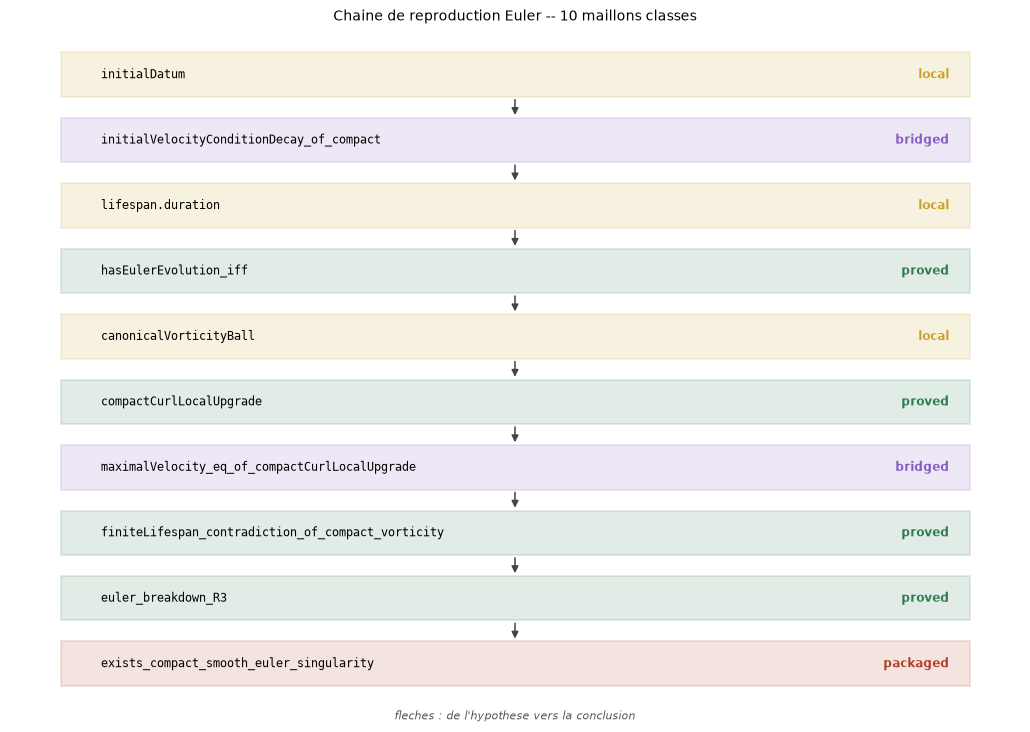

Repartition des classes : local=3, proved=4, bridged=2, packaged=1
Legende : upstream = amont, local = declare, proved = prouve,
          bridged = conversion de vocabulaire, packaged = assemblage.


In [4]:
# Code 2.2 - La chaine Euler en figure : chaque maillon colore par sa classe
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10.4, 7.4))
draw_chain(ax, EULER_CHAIN, "Chaine de reproduction Euler -- 10 maillons classes")
ax.text(0.5, 0.15, "fleches : de l'hypothese vers la conclusion",
        ha="center", fontsize=8, style="italic", color="#555555")
plt.tight_layout()
plt.show()

from collections import Counter

compte = Counter(classe for _n, classe, _d, _f in EULER_CHAIN)
print("Repartition des classes :",
      ", ".join(f"{classe}={compte[classe]}" for classe in CLASS_ENUM if compte[classe]))
print("Legende : upstream = amont, local = declare, proved = prouve,")
print("          bridged = conversion de vocabulaire, packaged = assemblage.")

### Lecture du résultat — la figure confirme la répartition : deux boîtes encadrent la partie prouvée, aucune boîte amont

La figure rend visible ce que le texte décrivait : la chaîne se lit de haut en bas, du datum initial (`initialDatum`) vers l'énoncé d'existence racine (`exists_…`), et la couleur de chaque boîte est sa classe. Trois régularités sautent aux yeux :

1. **l'alternance local / prouvé / converti** — les objets déclarés, les théorèmes et les deux conversions se relaient. Une chaîne exclusivement `local` ne prouverait rien ; une chaîne exclusivement `proved` cacherait d'où viennent ses objets ;
2. **les deux boîtes violettes (`bridged`) encadrent la partie prouvée** : une conversion d'entrée (`initialVelocityConditionDecay_of_compact`) et une conversion de sortie (`maximalVelocity_eq_of_compactCurlLocalUpgrade`). C'est le profil attendu d'une chaîne qui prouve dans un vocabulaire interne et rend son résultat dans le vocabulaire d'un défi ;
3. **aucune boîte grise (`upstream`)** — l'amont n'est pas un maillon, il est l'outillage des maillons.

La répartition affichée en bas de cellule est la **même information**, en chiffres : c'est elle que la section 4 agrègera avec les chaînes Navier–Stokes pour révéler les déséquilibres entre les branches.

## 3. Construction partagée, option (C), option (D)

### 3.1 Trois chaînes, et pourquoi il ne faut pas les confondre

Le fichier `NavierStokes/ComparatorSolution.lean` porte en tête :

> *« Navier–Stokes Comparator submission: options (C) and (D) »* — puis : *« Expose the project's proof adapters under the reference theorem names. The adapters import `ComparatorDefinitions`, never the challenge module »* (les adaptateurs importent `ComparatorDefinitions`, jamais le module du défi).

**Les options (C) et (D) sont deux soumissions au Comparator**, pas deux phases d'un même raisonnement. Chacune est une variante de l'énoncé de rupture, avec son propre vocabulaire de conditions initiales et de force :

| | **Option (C)** | **Option (D)** |
|---|---|---|
| Énoncé exposé | `NavierStokes.Comparator.navier_stokes_breakdown_R3` | `NavierStokes.Comparator.navier_stokes_breakdown_periodic` |
| Documenté comme | *« Breakdown of Navier–Stokes solutions on ℝ³ »* | *« Breakdown of Navier–Stokes solutions on ℝ³/ℤ³ »* |
| Conditions initiales | `Comparator.InitialVelocityConditionDecay u₀` | `Comparator.InitialVelocityConditionPeriodic u₀` |
| Force | `Comparator.ForceConditionDecay f` | `Comparator.ForceConditionPeriodic f` |
| Non-existence exigée | `¬ ∃ v p, Comparator.NavierStokesExistenceAndSmoothnessRn ν u₀ f v p` | `¬ ∃ v p, Comparator.NavierStokesExistenceAndSmoothnessPeriodic ν u₀ f v p` |
| Adaptateur interne | `option_C_of_compact_candidate` (`NavierStokes/ComparatorR3Theorem.lean`) | `option_D_of_candidate` (`NavierStokes/ComparatorTheorem.lean`) |
| Théorème de référence de l'adaptateur | `navier_stokes_breakdown_R3` | `navier_stokes_breakdown_periodic` |
| Témoin d'entrée | `R3CompactCandidate.Properties u p f` | `ProblemStatement.CandidateProperties u p f` |

**La construction du candidat est un troisième objet, partagé.** `ActualCandidateAssembly` produit un témoin (`selected_witness`), puis un candidat (`selected_candidate`, de type `ProblemStatement.candidateStatement`). Les deux branches le consomment, chacune par sa porte :

- la branche **(C)** passe par `R3ActualCandidate.selected_compact_candidate`, qui produit un `R3CompactCandidate.Properties` — la variante **ℝ³ entière** du candidat ;
- la branche **(D)** consomme directement `selected_candidate`, dont le type est le `CandidateProperties` **périodique**.

Appeler « option C » la construction partagée serait donc une erreur : la construction est **antérieure** au choix d'option, et elle est utilisée par les deux. C'est cette erreur que la décomposition en trois chaînes rend impossible à commettre.

**Deux modes d'exclusion, deux théorèmes amont internes.** Les deux adaptateurs n'excluent pas la solution globale par le même argument, et c'est là que leur différence est la plus substantielle :

| | Option (C) | Option (D) |
|---|---|---|
| Mécanisme | comparaison à **énergie finie sur tout ℝ³** : `R3FiniteEnergyComparison.compact_candidate_excludes_global_solution`, appuyé sur `NavierStokesR3.WholeSpaceUniqueness.classical_uniqueness_on_Icc` | **remise à l'échelle de viscosité** puis **durée de vie maximale** : `MaximalLifespan.candidate_excludes_global_solution`, appuyé sur `PeriodicUniqueness.classical_uniqueness_on_Icc` et `unbounded_excludes_continuous_extension` |
| Force utilisée | le candidat compact, remis à l'échelle par `ν²` | `f_ν(x,t) = ν² • f(ν·t, x)`, obtenue du candidat à viscosité 1 |
| Ce qui serait contradictoire | une solution globale à énergie finie uniforme pour la force compacte | une solution globale périodique, dont la restriction à `(0,2)` aurait une durée de vie `> 1` |
| Garantie d'indépendance | l'adaptateur conclut dans le vocabulaire `Comparator.*` sans nommer le module de défi | idem — en-tête : *« No result here uses any of the comparator's unproved statements »* |

Ces chaînes sont dites **d'adaptation** — et non de copie — parce qu'un port dans un lake CoursIA demanderait de choisir un cadre d'accueil cohérent en versions, d'adapter les estimateurs EDP et leurs dépendances, et de poser un probe par symbole. Copier un sous-arbre n'est pas une option : la règle de l'issue l'interdit explicitement.

construction partagee -- 3 maillons
 1. ActualCandidateConstruction [local   ] NavierStokes/ActualCandidateConstruction.lean
     module de construction : parameters / parameterSequence / cycle / ... (namespace NavierStokes.ActualCandidateConstruction)
 2. selected_witness       [proved  ] NavierStokes/ActualCandidateAssembly.lean
     theorem ActualCandidateAssembly.selected_witness : Witness ...
 3. selected_candidate     [proved  ] NavierStokes/ActualCandidateAssembly.lean
     theorem ActualCandidateAssembly.selected_candidate : ProblemStatement.candidateStatement

option (C) -- R3 -- 6 maillons
 1. selected_compact_candidate [proved  ] NavierStokes/R3ActualCandidate.lean
     theorem R3CompactCandidate.selected_compact_candidate : exists u p f, Properties u p f
 2. R3CompactCandidate.Properties [local   ] NavierStokes/R3CompactCandidate.lean
     structure R3CompactCandidate.Properties (u) (p) (f) : Prop
 3. compact_candidate_excludes_global_solution [proved  ] NavierStokes/R3Fini

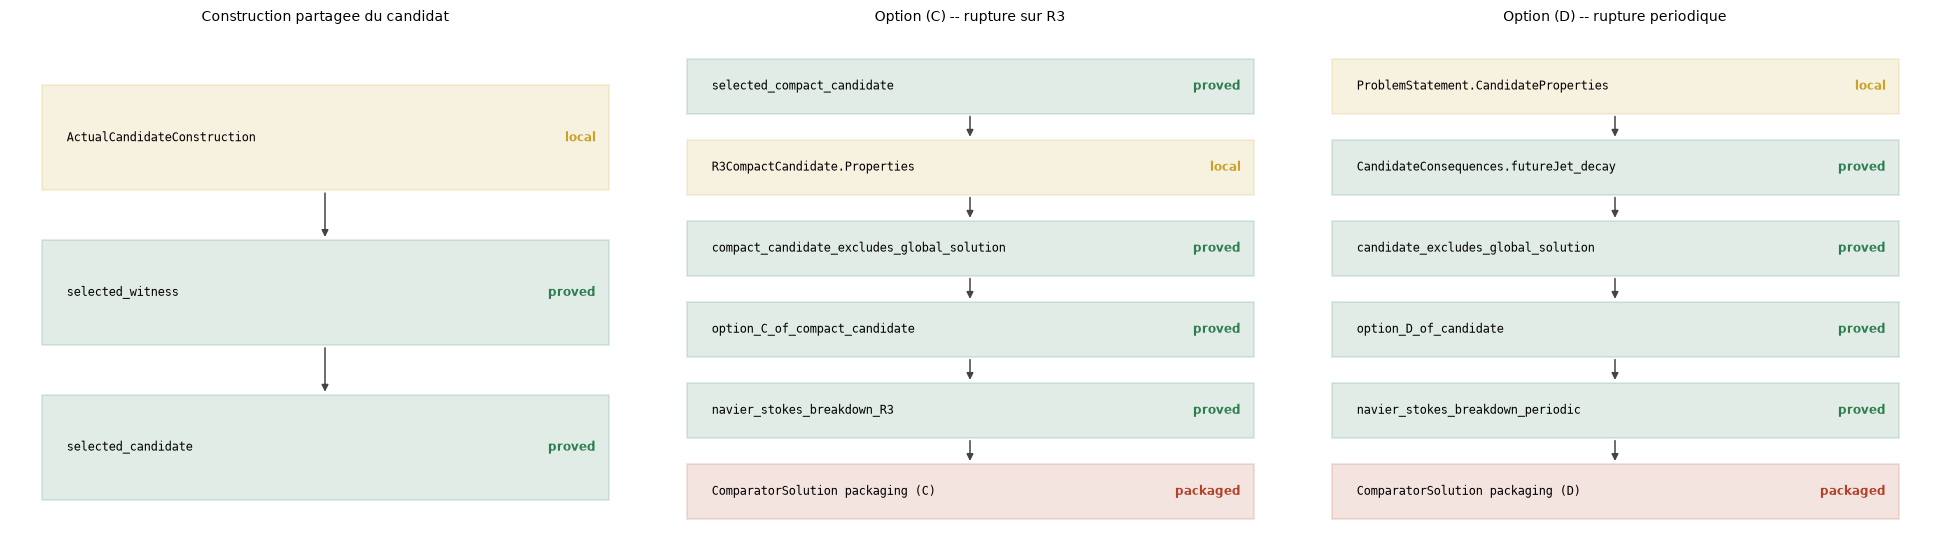

Lecture : la construction partagee alimente les DEUX options via deux portes
distinctes (selected_compact_candidate pour C, selected_candidate pour D).
Aucun maillon 'bridged' dans ces deux decompositions : la conversion de
vocabulaire est INTERNE aux adaptateurs, dont la conclusion est deja ecrite
dans le vocabulaire Comparator.* (contrairement a Euler, ou deux theoremes
de conversion nommes la portent).


In [5]:
# Code 3.1 - Trois chaines : construction partagee, option (C), option (D)
%matplotlib inline
import matplotlib.pyplot as plt

# Les options (C) et (D) sont les DEUX SOUMISSIONS du Comparator NS, telles que
# `NavierStokes/ComparatorSolution.lean` les expose. `NS_SHARED` est la construction
# de candidat, anterieure au choix d'option et consommee par les deux : l'appeler
# "option C" serait une erreur de lecture.
NS_SHARED = [
    ("ActualCandidateConstruction", "local",
     "module de construction : parameters / parameterSequence / cycle / ..."
     " (namespace NavierStokes.ActualCandidateConstruction)",
     "NavierStokes/ActualCandidateConstruction.lean"),
    ("selected_witness", "proved",
     "theorem ActualCandidateAssembly.selected_witness : Witness ...",
     "NavierStokes/ActualCandidateAssembly.lean"),
    ("selected_candidate", "proved",
     "theorem ActualCandidateAssembly.selected_candidate :"
     " ProblemStatement.candidateStatement",
     "NavierStokes/ActualCandidateAssembly.lean"),
]

NS_CHAIN_C = [
    ("selected_compact_candidate", "proved",
     "theorem R3CompactCandidate.selected_compact_candidate :"
     " exists u p f, Properties u p f",
     "NavierStokes/R3ActualCandidate.lean"),
    ("R3CompactCandidate.Properties", "local",
     "structure R3CompactCandidate.Properties (u) (p) (f) : Prop",
     "NavierStokes/R3CompactCandidate.lean"),
    ("compact_candidate_excludes_global_solution", "proved",
     "theorem (h : R3CompactCandidate.Properties u p f)"
     " (hv : GlobalSolutionRn f v q) : False",
     "NavierStokes/R3FiniteEnergyComparison.lean"),
    ("option_C_of_compact_candidate", "proved",
     "theorem (h : R3CompactCandidate.Properties u p f) (nu : R) (hnu : 0 < nu) :"
     " exists u0 f, Comparator.InitialVelocityConditionDecay u0 /\\"
     " Comparator.ForceConditionDecay f /\\ not (exists v p, ...Rn...)",
     "NavierStokes/ComparatorR3Theorem.lean"),
    ("navier_stokes_breakdown_R3", "proved",
     "theorem NavierStokes.ComparatorBridge.navier_stokes_breakdown_R3 (nu) (hnu)",
     "NavierStokes/ComparatorR3Theorem.lean"),
    ("ComparatorSolution packaging (C)", "packaged",
     "theorem NavierStokes.Comparator.navier_stokes_breakdown_R3 (nu) (hnu) :="
     " ComparatorBridge.navier_stokes_breakdown_R3 nu hnu",
     "NavierStokes/ComparatorSolution.lean"),
]

NS_CHAIN_D = [
    ("ProblemStatement.CandidateProperties", "local",
     "structure CandidateProperties (u) (p) (f) : Prop",
     "NavierStokes/ProblemStatement.lean"),
    ("CandidateConsequences.futureJet_decay", "proved",
     "decroissance des jets futurs de la force periodique a support temporel compact",
     "NavierStokes/CandidateConsequences.lean"),
    ("candidate_excludes_global_solution", "proved",
     "theorem MaximalLifespan.candidate_excludes_global_solution"
     " (h : CandidateProperties u p f) (hv) (hq) (hpv) (hpq) (hvzero)"
     " (hdv) (hNSv) : False",
     "NavierStokes/MaximalLifespan.lean"),
    ("option_D_of_candidate", "proved",
     "theorem (h : CandidateProperties u p f) (nu : R) (hnu : 0 < nu) :"
     " exists u0 f, Comparator.InitialVelocityConditionPeriodic u0 /\\"
     " Comparator.ForceConditionPeriodic f /\\ not (exists v p, ...Periodic...)",
     "NavierStokes/ComparatorTheorem.lean"),
    ("navier_stokes_breakdown_periodic", "proved",
     "theorem NavierStokes.ComparatorBridge.navier_stokes_breakdown_periodic (nu) (hnu)",
     "NavierStokes/ComparatorTheorem.lean"),
    ("ComparatorSolution packaging (D)", "packaged",
     "theorem NavierStokes.Comparator.navier_stokes_breakdown_periodic (nu) (hnu) :="
     " ComparatorBridge.navier_stokes_breakdown_periodic nu hnu",
     "NavierStokes/ComparatorSolution.lean"),
]

for titre, chaine in (("construction partagee", NS_SHARED),
                      ("option (C) -- R3", NS_CHAIN_C),
                      ("option (D) -- periodique", NS_CHAIN_D)):
    print(f"{titre} -- {len(chaine)} maillons")
    for index, (name, classe, decl, fichier) in enumerate(chaine, start=1):
        print(f"{index:2d}. {name:22s} [{classe:8s}] {fichier}")
        print(f"     {decl}")
    print()

fig, axes = plt.subplots(1, 3, figsize=(19.5, 5.6))
draw_chain(axes[0], NS_SHARED, "Construction partagee du candidat")
draw_chain(axes[1], NS_CHAIN_C, "Option (C) -- rupture sur R3")
draw_chain(axes[2], NS_CHAIN_D, "Option (D) -- rupture periodique")
plt.tight_layout()
plt.show()

print("Lecture : la construction partagee alimente les DEUX options via deux portes")
print("distinctes (selected_compact_candidate pour C, selected_candidate pour D).")
print("Aucun maillon 'bridged' dans ces deux decompositions : la conversion de")
print("vocabulaire est INTERNE aux adaptateurs, dont la conclusion est deja ecrite")
print("dans le vocabulaire Comparator.* (contrairement a Euler, ou deux theoremes")
print("de conversion nommes la portent).")

### Lecture du résultat — trois profils de classes : la construction partagée n'est pas « l'option C »

Les trois chaînes ont des **profils de classes distincts**, et c'est cela qu'il faut retenir :

| | Construction partagée | Option (C) | Option (D) |
|---|---|---|---|
| Longueur | 3 maillons | 6 maillons | 6 maillons |
| Dominante | `proved` + `local` | `proved` | `proved` |
| Emprunt amont nommé | — | — | — |
| Maillon `bridged` | — | — | — |
| Point d'assemblage | `selected_candidate` | porte d'entrée `selected_compact_candidate` | porte d'entrée `selected_candidate` |
| Empaquetage final | — | `ComparatorSolution` | `ComparatorSolution` |

Quatre conséquences, qui sont l'apport propre de cette section :

1. **la construction partagée n'est pas « l'option C ».** Sa porte d'entrée vers (C) est un théorème distinct (`R3ActualCandidate.selected_compact_candidate`) de son point d'arrivée (`selected_candidate`) ; la confondre avec (C) ferait disparaître la seule ligne de la figure qui explique pourquoi les deux options sont comparables ;
2. **les deux options se ressemblent structurellement** — même longueur, même absence de pont nommé, même empaquetage dans `ComparatorSolution` — et ne diffèrent que par le mécanisme d'exclusion et l'énoncé exposé. C'est le signe d'une **soumission double délibérée** : le projet veut que le même résultat soit disponible dans les deux vocabulaires du défi, pas qu'un raisonnement passe de l'un à l'autre ;
3. **il n'y a aucun maillon `bridged` dans ces décompositions**, alors qu'Euler en compte deux. Ce n'est pas une asymétrie de soin : les adaptateurs Navier–Stokes concluent **directement** dans le vocabulaire `Comparator.*` (`Comparator.InitialVelocityConditionDecay`, `Comparator.NavierStokesExistenceAndSmoothnessRn`, `…Periodic…`), donc la conversion est *interne* au théorème prouvé plutôt que d'être un maillon nommé. Côté Euler, le vocabulaire du défi est un `structure` (`InitialVelocityConditionDecay`) qu'un théorème séparé doit atteindre, et la représentation de solution doit être identifiée — d'où deux maillons `bridged` visibles ;
4. **le point d'appui interne est asymétrique.** (C) s'appuie sur la comparaison à énergie finie sur ℝ³ ; (D) s'appuie sur la durée de vie maximale et la remise à l'échelle de viscosité. Adapter l'une **ou** l'autre demande donc deux cadres de bibliothèque différents — c'est une information de décision, pas un détail.

> **Rappel de portée** : dans les deux cas, la conclusion porte sur **le candidat construit**, pas sur une solution quelconque. Ce que cela permet et ne permet pas de conclure est l'objet de la section 6, et c'en est le point le plus important.

## 4. Classer les maillons

### 4.1 Les cinq classes, définitions opératoires

Une classification n'a de valeur que si ses classes sont **testables**. Les cinq classes du protocole se définissent donc par un critère qu'on peut trancher en ouvrant le dépôt :

| Classe | Définition opératoire | Test de terrain |
|---|---|---|
| `upstream` | fourni par la bibliothèque amont (Mathlib, lake pinné) ; le dépôt le **consomme** | le symbole se résout sans être déclaré dans le dépôt |
| `local` | **déclaré** dans le dépôt, sans contenu de théorème à lui seul | `def` / `structure` / `abbrev`, ou construction sans preuve close |
| `proved` | porte la **substance** : un théorème établi dans le dépôt | `theorem` / `lemma` dont la preuve est close |
| `bridged` | **traduit** entre deux vocabulaires ou deux représentations (ℝ³ ↔ 𝕋³, interface interne ↔ interface de défi) | l'énoncé convertit sans ajouter de mathématiques nouvelles |
| `packaged` | **couche d'assemblage** qui rassemble des sous-résultats sous un nom de référence | extraction d'un témoin, espace de noms `Assembly`, ré-exposition sous un nom du défi |

Deux règles de discipline accompagnent cette grille :

- **une classe par maillon**. Un maillon mixte reçoit la classe de son **rôle dominant**, et la note signalerait explicitement la mixture. Refuser de trancher reviendrait à rendre la classe inutilisable ;
- **l'énumération est fermée**. Un maillon dont la classe sortirait des cinq valeurs est un **défaut de classification**, pas une sixième classe. La cellule suivante le vérifie.

Le point sensible de la grille est la frontière `proved` / `bridged` / `packaged` :

- un théorème qui **démontre** une propriété mathématique est `proved`, même si son énoncé parle de deux objets ;
- un théorème dont le contenu est **l'identification de deux écritures du même objet** est `bridged` ;
- un théorème qui **ne démontre rien de neuf** et se contente de ré-exposer un résultat existant sous un nom attendu est `packaged`.

Les deux adaptations Navier–Stokes de `ComparatorSolution.lean` tombent dans la troisième catégorie : leur corps est un unique appel à l'adaptateur (`exact ComparatorBridge.navier_stokes_breakdown_R3 nu hnu`). Les compter comme `proved` gonflerait artificiellement la substance et masquerait que **le contenu est dans l'adaptateur**, pas dans la ré-exposition.

chaine         upstream     local    proved   bridged  packaged   total
Euler                 0         3         4         2         1      10
NS partagee           0         1         2         0         0       3
NS (C)                0         1         4         0         1       6
NS (D)                0         1         4         0         1       6

Total : 25 maillons
Classes hors enumeration : aucune
Maillons sans fichier    : aucun
Classes jamais utilisees : ['upstream']
Ou apparait 'bridged'    : ['Euler']


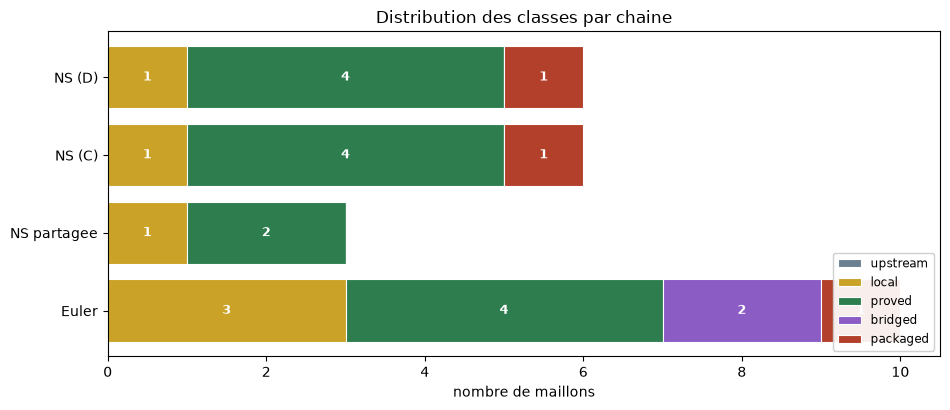

In [6]:
# Code 4.1 - Comptage par classe, validation de l'enumeration, figure de synthese
%matplotlib inline
import matplotlib.pyplot as plt

CHAINS = {
    "Euler": EULER_CHAIN,
    "NS partagee": NS_SHARED,
    "NS (C)": NS_CHAIN_C,
    "NS (D)": NS_CHAIN_D,
}

comptes = {titre: {classe: 0 for classe in CLASS_ENUM} for titre in CHAINS}
hors_enum = []
sans_fichier = []
for titre, chaine in CHAINS.items():
    for name, classe, decl, fichier in chaine:
        if classe in CLASS_ENUM:
            comptes[titre][classe] += 1
        else:
            hors_enum.append((titre, name, classe))
        if not fichier.endswith(".lean"):
            sans_fichier.append((titre, name, fichier))

entete = " ".join(f"{classe:>9s}" for classe in CLASS_ENUM)
print(f"{'chaine':13s} {entete}   total")
for titre in CHAINS:
    ligne = " ".join(f"{comptes[titre][classe]:9d}" for classe in CLASS_ENUM)
    print(f"{titre:13s} {ligne}   {len(CHAINS[titre]):5d}")

total = sum(len(chaine) for chaine in CHAINS.values())
print(f"\nTotal : {total} maillons")
print(f"Classes hors enumeration : {hors_enum if hors_enum else 'aucune'}")
print(f"Maillons sans fichier    : {sans_fichier if sans_fichier else 'aucun'}")
jamais = [c for c in CLASS_ENUM if all(comptes[t][c] == 0 for t in CHAINS)]
print(f"Classes jamais utilisees : {jamais if jamais else 'aucune'}")
print(f"Ou apparait 'bridged'    : "
      f"{[t for t in CHAINS if any(c == 'bridged' for _n, c, _d, _f in CHAINS[t])] or 'nulle part'}")

fig, ax = plt.subplots(figsize=(9.6, 4.2))
positions = list(range(len(CHAINS)))
cumul = [0] * len(CHAINS)
for classe in CLASS_ENUM:
    valeurs = [comptes[titre][classe] for titre in CHAINS]
    ax.barh(positions, valeurs, left=cumul, color=CLASS_COLORS[classe],
            edgecolor="white", linewidth=0.8, label=classe)
    for y, (valeur, decalage) in enumerate(zip(valeurs, cumul)):
        if valeur:
            ax.text(decalage + valeur / 2, y, str(valeur), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    cumul = [a + b for a, b in zip(cumul, valeurs)]
ax.set_yticks(positions)
ax.set_yticklabels(list(CHAINS))
ax.set_xlabel("nombre de maillons")
ax.set_title("Distribution des classes par chaine")
ax.legend(loc="lower right", fontsize=8.5, framealpha=0.92)
plt.tight_layout()
plt.show()

### Lecture du résultat — vingt-cinq maillons, aucun hors énumération, aucun sans fichier : une classification contredisible

Le tableau et la figure donnent la **même mesure sous deux formes**. Ce qu'ils révèlent :

| Mesure | Valeur observée | Ce qu'elle signifie |
|---|---|---|
| Classe hors énumération | aucune | la grille des cinq classes **recouvre** les vingt-cinq maillons : la classification est applicable telle quelle |
| Maillon sans fichier `.lean` | aucun | chaque maillon est rattaché à une déclaration située : la classification est **auditable ligne à ligne** |
| Classe jamais utilisée | `upstream` | aucune chaîne ne compte l'amont comme maillon — Mathlib outille les preuves sans y figurer |
| Localisation de `bridged` | Euler uniquement | les adaptateurs Navier–Stokes concluent directement dans le vocabulaire du défi ; Euler a besoin de deux théorèmes de conversion nommés |

La deuxième ligne est celle qui distingue cette classification d'un jugement de rôle : chaque entrée porte un fichier, donc un lecteur peut ouvrir le fichier et contredire la classe. Une classe qu'on ne peut pas contredire n'informe personne.

Les barres de la figure rendent visible le contraste de **profil** : partout dominées par les théorèmes (`proved`), avec les portions jaunes (`local`) qui marquent les objets déclarés et les portions rouges (`packaged`) qui marquent les ré-expositions sous un nom de défi.

**Ce que ce comptage ne prouve pas** : qu'une classe soit « mieux » qu'une autre. Un maillon `local` n'est pas un maillon faible — une chaîne de preuve a besoin d'objets bien posés. Le comptage sert à **localiser la substance**, pas à noter la chaîne.

> **Le contrôle qui reste possible** : ouvrir chaque fichier cité et vérifier l'appartenance de classe — un `proved` qui porterait un `sorry`, un `bridged` qui démontrerait en fait un théorème de contenu, un `packaged` qui aurait un corps non trivial. Les fichiers sont nommés précisément pour que ce contrôle soit possible, et il peut **contredire** ce tableau.

## 5. Re-dériver le verdict depuis les feuilles

### 5.1 Ne pas croire `all_verified`

Le rapport du harnais porte un champ de synthèse, `all_verified`. Le réflexe naturel — le lire et le croire — est exactement le réflexe qu'un vérificateur doit combattre : **un résumé est une affirmation, les feuilles sont l'évidence**. La conjonction du harnais se recompose ainsi, avec **huit** termes :

$$
\texttt{all\_verified} \;=\; \texttt{sha\_matches\_pin} \;\wedge\; \texttt{dependency\_pins\_match} \;\wedge\; \texttt{toolchain\_matches} \;\wedge\; \texttt{confinement.verified} \;\wedge\; \texttt{axioms\_within\_permitted} \;\wedge\; \texttt{forbidden\_axioms} = [\,] \;\wedge\; \texttt{integrity.verified} \;\wedge\; \bigwedge_{\text{gate}} \texttt{gate.verified}
$$

Trois de ces termes sont faciles à oublier dans une re-dérivation écrite de mémoire : `dependency_pins_match` (les revs de `Comparator`, `mathlib`, `lean4export` **et** le rev du noyau nanoda), `confinement.verified` (identité de `landrun` et probe fonctionnel refus/autorisation) et `integrity.verified` (le recensement externe des sources suivies). Un rapport dont les gates sont verts mais l'un de ces trois termes faux n'est pas une reproduction confinée.

Chaque `gate.verified` se décompose à son tour en quatre feuilles :

| Feuille du gate | Condition |
|---|---|
| processus | statut `ok`, code de sortie enfant nul, code de sortie nul, processus **non tué** |
| orphelins | la postcondition d'orphelins est satisfaite (aucun processus résiduel) |
| sémantique | les **deux** kernels acceptent, le verdict de succès est présent, aucune marque de rejet |
| empreinte | l'empreinte du JSON de challenge égale l'empreinte attendue |

La cellule suivante recalcule cette conjonction **à partir des feuilles** et la compare au champ déclaré. Elle exige exactement les deux gates attendus, vérifie les onze sondes axiomatiques, les quatre signatures de placeholders et la forme des empreintes annoncées.

In [7]:
# Code 5.1 - Re-derivation independante de la conjonction, feuille par feuille
#
# Le rapport porte un champ de synthese `all_verified`. On ne le lit pas comme une
# preuve : on recalcule la conjonction depuis les feuilles, puis on compare.
# Le moindre desaccord est un finding -- pas un detail d'affichage.
EXPECTED_GATES = {"euler", "navier_stokes"}
EXPECTED_CHALLENGE_SORRIES = {
    ("ComparatorChallenges/Euler.lean", "euler_breakdown_R3", 1),
    ("ComparatorChallenges/Euler.lean", "exists_compact_smooth_euler_singularity", 1),
    ("ComparatorChallenges/NavierStokes.lean", "navier_stokes_breakdown_R3", 1),
    ("ComparatorChallenges/NavierStokes.lean", "navier_stokes_breakdown_periodic", 1),
}


def gate_verified(gate):
    """Recalcule les quatre feuilles d'un gate, sans lire son résumé `verified`."""
    leaves = {
        "process_ok": (
            gate.get("status") == "ok"
            and gate.get("child_exit_code") == 0
            and gate.get("exit_code") == 0
            and gate.get("killed") is False
        ),
        "orphan_ok": gate.get("orphans") == [] and bool(
            gate.get("orphan_postcondition_ok")
        ),
        "semantic_ok": (
            gate.get("kernels") == {"nanoda": "accepts", "lean_kernel": "accepts"}
            and gate.get("semantic_verdict") == "Your solution is okay!"
            and gate.get("semantic_rejection") is False
        ),
        "hash_ok": bool(gate.get("challenge_hash_matches")),
    }
    return all(leaves.values()), leaves


def rederive_all_verified(report, gates, integrity):
    """Recalcule les huit termes du harnais depuis les feuilles disponibles."""
    named_axioms = report.get("axiom_declarations")
    challenge_sorries = integrity.get("challenge_sorry_locations")
    observed_sorries = {
        (item.get("file"), item.get("declaration"), item.get("count"))
        for item in challenge_sorries
        if isinstance(item, dict)
    } if isinstance(challenge_sorries, list) else set()
    gate_leaves = {name: gate_verified(gate)[0] for name, gate in gates.items()}
    confinement = report.get("confinement")
    conditions = {
        "sha_matches_pin": (
            bool(report.get("sha_matches_pin"))
            and report.get("observed_sha") == PINNED_SHA
        ),
        "dependency_pins_match": bool(report.get("dependency_pins_match")),
        "toolchain_matches": (
            bool(report.get("toolchain_matches"))
            and report.get("toolchain") == TOOLCHAIN
        ),
        "confinement_verified": (
            isinstance(confinement, dict)
            and confinement.get("engine") == "landrun"
            and confinement.get("version") == "landrun version 0.1.17"
            and confinement.get("unauthorized_write_denied") is True
            and confinement.get("authorized_write_allowed") is True
            and confinement.get("verified") is True
        ),
        "axioms_within_permitted": (
            bool(report.get("axioms_within_permitted"))
            and isinstance(named_axioms, list)
            and len(named_axioms) == len(set(named_axioms))
            and set(named_axioms) == set(EXPECTED_AXIOM_DECLARATIONS)
        ),
        "aucun_axiome_interdit": report.get("forbidden_axioms") == [],
        "integrity_verified": (
            bool(integrity.get("verified"))
            and observed_sorries == EXPECTED_CHALLENGE_SORRIES
            and integrity.get("solution_sorry_proof_count") == 0
            and integrity.get("native_decide_count") == 0
        ),
        "tous_les_gates_verifies": (
            set(gates) == EXPECTED_GATES and all(gate_leaves.values())
        ),
    }
    return all(conditions.values()), conditions, gate_leaves


rederived, conditions, gate_leaves = rederive_all_verified(REPORT, GATES, INTEGRITY)
for nom, valeur in conditions.items():
    print(f"  {nom:26s} : {valeur}")
declare = bool(REPORT.get("all_verified"))
print()
print(f"  conjonction recalculee : {rederived}")
print(f"  champ declare          : {declare}")
print(f"  concordance            : {rederived == declare}")
print()
print("  Feuilles par gate (recalculees sans lire `gate.verified`) :")
for nom, gate in sorted(GATES.items()):
    verified, leaves = gate_verified(gate)
    print(f"    {nom:14s} process={leaves['process_ok']} "
          f"orphelins={leaves['orphan_ok']} semantique={leaves['semantic_ok']} "
          f"empreinte={leaves['hash_ok']} -> recalcule={verified} "
          f"declare={gate.get('verified')}")
print()
print("  Recensement d'integrite :")
for cle in ("scanner", "tracked_lean_files", "root_sha_matches",
            "challenge_sorry_proof_count", "solution_sorry_proof_count",
            "native_decide_count", "complete", "verified"):
    print(f"    {cle:30s} : {field(INTEGRITY, cle)}")
observed_signature = {
    (item.get("file"), item.get("declaration"), item.get("count"))
    for item in INTEGRITY.get("challenge_sorry_locations", [])
    if isinstance(item, dict)
}
print(f"    signatures challenge exactes : {observed_signature == EXPECTED_CHALLENGE_SORRIES}")
print()
print("  Empreintes observees vs attendues :")
for nom in sorted(EXPECTED_CHALLENGE_SHA256):
    observee = GATES.get(nom, {}).get("challenge_sha256", "<absent>")
    attendue = EXPECTED_CHALLENGE_SHA256[nom]
    verdict = "concordent" if observee == attendue else "DESACCORD"
    print(f"    {nom:14s} {str(observee)[:20]}... vs {attendue[:20]}...  -> {verdict}")
print()
print("  Forme des empreintes -- 64 hex attendus pour les challenges :",
      all(re.fullmatch(r"[0-9a-f]{64}", h) for h in EXPECTED_CHALLENGE_SHA256.values()),
      "| 40 hex attendus pour le pin :", bool(re.fullmatch(r"[0-9a-f]{40}", PINNED_SHA)))
print()
print("  Preuves d'axiomes nommees :")
OBSERVED_DECLS = REPORT.get("axiom_declarations")
if isinstance(OBSERVED_DECLS, list):
    observed_set = set(OBSERVED_DECLS)
    expected_set = set(EXPECTED_AXIOM_DECLARATIONS)
    print("    conjonction d'ensembles :",
          "IDENTIQUE" if observed_set == expected_set else "DESACCORD")
    print(f"    cibles manquees    : {sorted(expected_set - observed_set) or 'aucune'}")
    print(f"    sondes inattendues : {sorted(observed_set - expected_set) or 'aucune'}")
    print(f"    nombre de sondes   : {len(OBSERVED_DECLS)} observe,"
          f" {len(EXPECTED_AXIOM_DECLARATIONS)} attendu")
else:
    print("    champ axiom_declarations ABSENT du rapport -- preuve nommee indisponible")
print(f"    chaque sonde porte exactement le trio permis :"
      f" {field(REPORT, 'axioms_within_permitted')}")

  sha_matches_pin            : True
  dependency_pins_match      : True
  toolchain_matches          : True
  confinement_verified       : True
  axioms_within_permitted    : True
  aucun_axiome_interdit      : True
  integrity_verified         : True
  tous_les_gates_verifies    : True

  conjonction recalculee : True
  champ declare          : True
  concordance            : True

  Feuilles par gate (recalculees sans lire `gate.verified`) :
    euler          process=True orphelins=True semantique=True empreinte=True -> recalcule=True declare=True
    navier_stokes  process=True orphelins=True semantique=True empreinte=True -> recalcule=True declare=True

  Recensement d'integrite :
    scanner                        : scripts/lean/count_code_sorry.py:scan_file
    tracked_lean_files             : 2486
    root_sha_matches               : True
    challenge_sorry_proof_count    : 4
    solution_sorry_proof_count     : 0
    native_decide_count            : 0
    complete            

### Lecture du résultat — trois termes de la conjonction sont invisibles depuis les enregistrements de gate

Trois enseignements de nature différente, qu'il faut garder séparés.

**1. La re-dérivation rend le recouvrement des clauses d'axiomes visible.** `axioms_within_permitted` exige que les onze déclarations sondées soient exactement les cibles attendues, chacune portant exactement le trio permis — et le harnais est durci : un sondage **répété** annule la preuve nommée au lieu de grossir le compte ; `forbidden_axioms`, lui, balaie **toutes** les listes d'axiomes imprimées. Les deux clauses se recouvrent largement sans être logiquement identiques — l'une certifie les cibles, l'autre surveille tout ce qui s'imprime. Les garder toutes deux dans la conjonction est une ceinture et des bretelles, et la re-dérivation permet de le **constater** au lieu de le supposer.

**2. Trois termes de la conjonction sont invisibles depuis les gates.** `dependency_pins_match`, `confinement.verified` et `integrity.verified` ne se lisent nulle part dans les enregistrements `gate`. Un lecteur qui aurait contrôlé les deux gates un par un — kernels, empreintes, verdict sémantique, orphelins — aurait pu déclarer la reproduction valide sans vérifier les dépendances, l'application fonctionnelle du confinement ou la complétude du recensement des sources suivies. **C'est le principal apport de cette section** : la liste des feuilles n'est pas devinable depuis les objets les plus visibles du rapport.

Le probe de confinement ne se contente pas du nom d'un binaire : il exige `landrun version 0.1.17`, vérifie qu'une écriture non autorisée sous le home est refusée et qu'une écriture explicitement autorisée sous `/tmp` réussit. Les deux observations sont nécessaires ; un binaire présent mais inopérant ne suffit pas.

**3. Les empreintes et signatures sont confrontées aux contrats exacts.** Les empreintes observées sont affichées face aux attendues. Le recensement compare également les quatre triplets `(fichier, déclaration, compte)` des placeholders de challenge, exige zéro placeholder dans les solutions et zéro `native_decide`. Un total de quatre sans localisation exacte serait insuffisant : déplacer un trou du challenge vers une solution conserverait le total tout en détruisant l'intégrité recherchée.

> **Note de méthode** : c'est la fonction d'un organe de contrôle que de rendre la conjonction **recomposable** plutôt que de la laisser dormir dans un booléen. La section 7 en fait un exercice.

> **Note — les onze cibles d'axiomes et les chaînes de ce notebook**. Les déclarations sondées par le harnais sont énumérées nommément : les deux adaptateurs, leurs deux théorèmes d'exclusion, les quatre énoncés exigés par les deux challenges, les deux théorèmes BKM — et la contrepartie au niveau *packet* du dernier maillon d'Euler, homonyme exact de celui-ci. Que seuls les noms **qualifiés** distinguent les homonymes est une raison de plus pour confronter l'ensemble observé aux onze cibles, au lieu de se fier au seul compte.

> **Note — les quatre `sorry` de challenge**. La signature exacte exige un placeholder pour `euler_breakdown_R3` et `exists_compact_smooth_euler_singularity` dans `ComparatorChallenges/Euler.lean`, puis un pour `navier_stokes_breakdown_R3` et `navier_stokes_breakdown_periodic` dans `ComparatorChallenges/NavierStokes.lean`. Ce sont les trous attendus du côté défi ; côté solution, le compte doit rester à zéro.

## 6. Portée, limites et non-claims

Cette section est la plus importante du notebook, parce qu'elle énonce ce que **rien** de ce qui précède ne permet de conclure.

### 6.1 Ce qu'un gate vert établit

Le rapport porte `all_verified: true` avec l'ensemble de ses huit termes satisfaits. Les faits suivants sont alors établis :

| Fait établi | Portée exacte |
|---|---|
| le checkout est au pin `8937a8f4…` | identité du **code source** examiné |
| les pins de dépendances concordent | reproductibilité de la **chaîne de dépendances**, pas seulement de l'arbre principal |
| la toolchain est celle déclarée | reproductibilité de l'**outillage** |
| le confinement est fonctionnel | `landrun` est à la version attendue ; une écriture hors périmètre est refusée et une écriture autorisée réussit |
| les deux kernels acceptent l'artefact | l'artefact est **dérivable** dans le noyau Lean standard **et** dans un noyau alternatif indépendant (nanoda) |
| les seuls axiomes utilisés sont `propext`, `Classical.choice`, `Quot.sound` | les onze déclarations porteuses sont sondées **nommément**, chacune avec exactement ce trio — pas de `sorryAx` transitif, pas de réduction par le noyau natif déguisée |
| le recensement d'intégrité est complet et vérifié | les quatre signatures attendues sont localisées côté challenge ; les solutions portent zéro `sorry` et zéro `native_decide` |
| aucun processus orphelin ne subsiste | la mesure n'a pas été polluée par un processus résiduel |

### 6.2 Ce qu'un gate vert n'établit **pas**

| Non-claim | Pourquoi |
|---|---|
| **que l'exposition est juste** | le noyau vérifie un artefact, pas la lecture qu'on en fait ; les sections 2 et 3 sont de l'exposition |
| **que l'énoncé est nouveau ou intéressant** | la vérification est aveugle à la valeur mathématique et à l'antériorité |
| **qu'un lecteur humain accepterait la preuve** | l'acceptation mécanique ne remplace pas la relecture, elle la déplace |
| **que la classification de la section 4 est exacte** | elle est fondée sur des déclarations citées, donc réfutable — mais elle n'a pas été recontrôlée fichier par fichier dans ce notebook |
| **que le candidat est l'objet que le défi visait** | les adaptateurs prouvent une propriété du candidat **construit** ; l'identification de cet objet à un objet mathématiquement intéressant est un jugement externe |
| **que le problème du millénaire sur Navier–Stokes est résolu** | voir 6.3 — c'est le point le plus important |

### 6.3 Le non-claim central

**Ce notebook n'affirme pas, et le rapport du harnais n'établit pas, que le problème du millénaire sur l'existence et la régularité des solutions de Navier–Stokes soit résolu.**

Ce qui est rapporté est plus étroit, et doit être énoncé avec précision. Les deux adaptateurs établissent une propriété d'**exclusion portant sur le candidat construit** :

- l'option (C) exclut toute solution globale à énergie finie uniforme pour la force compacte remise à l'échelle, par comparaison sur ℝ³ entier ;
- l'option (D) exclut toute solution globale périodique pour la force `f_ν`, en la remettant à l'échelle vers une solution globale à viscosité 1, ce qui contredit la durée de vie maximale égale à un.

Dans les deux cas, le théorème d'exclusion est **conditionné à l'existence du témoin de candidat**, obtenu par `selected_candidate` / `selected_compact_candidate`. Trois écarts séparent une telle affirmation d'une résolution du problème du millénaire, et aucun n'est franchi par une acceptation de noyau :

1. **l'écart de portée** : une exclusion portant sur *un* candidat n'est pas une exclusion portant sur *toutes* les solutions admissibles ;
2. **l'écart d'énoncé** : faire coïncider l'énoncé formel des challenges Comparator et l'énoncé précis du problème du millénaire est un travail mathématique, non un travail de vérification ;
3. **l'écart d'arbitrage** : décider qu'un énoncé formalisé *est bien* l'énoncé du problème est un jugement de communauté, qui ne se délègue ni à un noyau ni à un notebook.

Un noyau est un instrument d'une **précision** remarquable et d'une **portée** étroite : il dit qu'une dérivation est correcte, jamais que le problème visé est celui qu'on croit.

### 6.4 Une contrainte d'environnement, pas de mathématiques

Les exécutions Comparator que le harnais relit ont tourné sous un sandbox noyau — `landrun`, fondé sur **Landlock** de Linux — et leurs artefacts vivent dans un home WSL. Un hôte Windows natif ne peut pas les rejouer directement : ce n'est ni une impossibilité mathématique ni une raison de dégrader la mesure. Le probe fonctionnel du rapport démontre ici que le mécanisme requis était actif.

| Situation | Lecture correcte |
|---|---|
| un échec local du sandbox | « cet hôte ne porte pas le mécanisme requis » — jamais « l'outil est intrinsèquement impossible » |
| un `all_verified: false` | « le gate n'a pas été franchi **ici** », pas « le résultat est faux » |
| un succès local | l'artefact est accepté **pour ces pins** — pas une validité générale, pas une preuve de nouveauté |

## 7. Exercices

Les trois exercices suivants prolongent le notebook sans le répéter : ils portent sur la **réutilisation** de ce qui a été démontré, pas sur sa recopie. Chacun s'appuie sur des objets déjà en mémoire et demande un travail que les cellules de démonstration n'ont pas fait.

### Exercice 1 — Re-dériver le prédicat d'un gate à partir de ses quatre feuilles

La cellule 5.1 a recalculé la conjonction **au niveau du rapport**, en prenant `gate.verified` comme donné. L'exercice demande de descendre d'un cran : reconstruire `verified` **depuis les feuilles** d'un enregistrement de gate.

**Objectif** : écrire une fonction réutilisable `gate_verified(gate)` qui retourne le booléen **et** le détail des quatre feuilles.

**Étapes** :

1. `process_ok` — statut `ok`, code de sortie enfant nul, code de sortie nul, processus non tué ;
2. `orphan_ok` — la postcondition d'orphelins est satisfaite ;
3. `semantic_ok` — les deux kernels acceptent, le verdict sémantique est présent, aucune marque de rejet ;
4. `hash_ok` — la concordance d'empreinte ; puis `verified` = conjonction des quatre.

**Pourquoi c'est utile** : une fonction de ce type est ce qui permet de rejouer un rapport **ancien** contre les règles **courantes**, et donc de détecter qu'une règle de vérification a changé — ce qu'un champ de synthèse figé ne peut pas signaler. Attention à l'ordre : une feuille oubliée rend la fonction **plus permissive** que le harnais, ce qui est le sens de l'erreur le plus dangereux.

In [8]:
# Exercice 1 - Re-deriver le predicat d'un gate depuis ses quatre feuilles
# Etape 1 : process_ok  = status == "ok" ET child_exit_code == 0 ET exit_code == 0 ET killed is False
# Etape 2 : orphan_ok   = la postcondition d'orphelins est satisfaite
# Etape 3 : semantic_ok = les deux kernels acceptent ET le verdict semantique est present
#                        ET aucune rejection n'a ete detectee
# Etape 4 : hash_ok     = challenge_hash_matches est vrai
#           verified    = process_ok ET orphan_ok ET semantic_ok ET hash_ok
# Indice : la cellule 5.1 imprime deja la decomposition d'un gate reel ; l'exercice porte
#          sur la fonction REUTILISABLE. Une feuille oubliee rend la fonction plus
#          permissive que le harnais : c'est l'erreur a ne pas commettre.

def gate_verified(gate):
    """Retourne (verified, detail) ; `detail` est un dict des quatre feuilles."""
    return None  # TODO etudiant : calculer les quatre feuilles puis leur conjonction


exemple = sorted(GATES)[0] if GATES else None
print(f"Gate de reference : {exemple if exemple is not None else 'ABSENT du rapport'}")
if exemple is not None:
    print(f"  champs disponibles : {sorted(GATES[exemple])}")
    print(f"  retour de gate_verified : {gate_verified(GATES[exemple])}")
print("Indice : aucune feuille ne se lit dans le champ de synthese `verified` du rapport.")

Gate de reference : euler
  champs disponibles : ['backend', 'challenge_hash_matches', 'challenge_sha256', 'child_exit_code', 'duration_s', 'ended_utc', 'exit_code', 'kernels', 'killed', 'orphan_postcondition_ok', 'orphans', 'semantic_rejection', 'semantic_verdict', 'started_utc', 'status', 'stderr_sha256', 'stdout_sha256', 'verified']
  retour de gate_verified : None
Indice : aucune feuille ne se lit dans le champ de synthese `verified` du rapport.


### Exercice 2 — Classer des déclarations du source pinné

La section 4 a classé les maillons **des chaînes de preuve**. L'exercice demande d'appliquer la grille à des déclarations nommées, et d'expliciter **pourquoi** chacune tombe dans sa classe.

**Objectif** : écrire `classify(declarations)` qui retourne, pour chaque entrée, un couple `(classe, raison)`.

**Les quatre candidats** :

| Déclaration | Fichier |
|---|---|
| `Euler.ComparatorBridge.compactCurlLocalUpgrade` | `Euler/ComparatorLocalEvolution.lean` |
| `Euler.InitialVelocityConditionDecay` | `Euler/SolutionDefinitions.lean` |
| `NavierStokes.Comparator.navier_stokes_breakdown_periodic` | `NavierStokes/ComparatorSolution.lean` |
| `Mathlib.Analysis.Distribution.SchwartzSpace.Basic` | amont (Mathlib) |

**Étapes** :

1. proposer une classe par déclaration, en citant dans la raison **le critère de la grille** qui l'emporte ;
2. vérifier que chaque classe proposée appartient à l'énumération fermée — la cellule 4.1 montre la vérification d'appartenance ;
3. signaler le cas le plus instructif : une déclaration peut être `local` **pour le dépôt qui la porte** alors qu'elle a été **adaptée d'une source externe**. C'est le cas de `InitialVelocityConditionDecay` : le dépôt en déclare sa propre version, dérivée de `FormalConjectures/Millenium/NavierStokes.lean`, et ne l'importe pas du module de défi.

**Pourquoi c'est utile** : c'est en classant des déclarations réelles qu'on découvre que `local` ne veut pas dire « inventé ici » mais « **déclaré ici, sans contenu de théorème propre** ». Nommer ce glissement est ce qui distingue un census d'un inventaire.

In [9]:
# Exercice 2 - Classer des declarations du source pine
# Les quatre candidats sont des symboles reellement presents dans le depot pine.
# Etape 1 : proposer UNE classe parmi {upstream, local, proved, bridged, packaged}
#           pour chacun, en citant le critere de la grille qui l'emporte.
# Etape 2 : verifier que chaque classe proposee appartient a l'enumeration fermee
#           (la cellule 4.1 montre la verification d'appartenance).
# Etape 3 : traiter le cas de `InitialVelocityConditionDecay` : declare dans le depot,
#           adapte d'une source externe (`FormalConjectures/Millenium/NavierStokes.lean`),
#           et pourtant `local` dans la grille. Dire pourquoi.
# Indice : l'en-tete de `Euler/SolutionDefinitions.lean` dit verbatim :
#          "This module contains no challenge theorem or proof placeholder
#           and does not import `Euler`."

A_CLASSER = (
    ("Euler.ComparatorBridge.compactCurlLocalUpgrade", "Euler/ComparatorLocalEvolution.lean"),
    ("Euler.InitialVelocityConditionDecay", "Euler/SolutionDefinitions.lean"),
    ("NavierStokes.Comparator.navier_stokes_breakdown_periodic", "NavierStokes/ComparatorSolution.lean"),
    ("Mathlib.Analysis.Distribution.SchwartzSpace.Basic", "amont (Mathlib)"),
)
propose = None  # TODO etudiant : tuple de (declaration, classe, raison) dans le meme ordre


print("Exercice a completer : classement des quatre declarations.")
print(f"Enumeration fermee : {', '.join(CLASS_ENUM)}")
print(f"Candidats : {len(A_CLASSER)}")
for decl, fichier in A_CLASSER:
    print(f"  {decl:52s} {fichier}")
print(f"Retour de classify : {propose}")

Exercice a completer : classement des quatre declarations.
Enumeration fermee : upstream, local, proved, bridged, packaged
Candidats : 4
  Euler.ComparatorBridge.compactCurlLocalUpgrade       Euler/ComparatorLocalEvolution.lean
  Euler.InitialVelocityConditionDecay                  Euler/SolutionDefinitions.lean
  NavierStokes.Comparator.navier_stokes_breakdown_periodic NavierStokes/ComparatorSolution.lean
  Mathlib.Analysis.Distribution.SchwartzSpace.Basic    amont (Mathlib)
Retour de classify : None


### Exercice 3 — Comparer les deux adaptateurs du Comparator

Les options (C) et (D) sont deux **soumissions** du même projet au Comparator Navier–Stokes. Elles se ressemblent par leur forme — même longueur de chaîne, même énumération de conditions, même empaquetage — et diffèrent par leur **mécanisme d'exclusion**. L'exercice demande de mettre cette différence sous forme comparable.

**Objectif** : écrire `compare_options(c, d)` qui retourne un tableau comparatif des deux adaptateurs selon cinq axes, chaque cellule étant extraite des déclarations déjà lues.

**Les cinq axes** :

1. **vocabulaire des conditions initiales** — `InitialVelocityConditionDecay` vs `InitialVelocityConditionPeriodic` ;
2. **forme de la force** — la force compacte du candidat remise à l'échelle, vs `f_ν(x,t) = ν² • f(ν·t, x)` ;
3. **théorème d'exclusion consommé** — `R3FiniteEnergyComparison.compact_candidate_excludes_global_solution` vs `MaximalLifespan.candidate_excludes_global_solution` ;
4. **raison d'être de l'exclusion** — comparaison à énergie finie sur ℝ³ entier vs remise à l'échelle de viscosité contredisant la durée de vie maximale d'un ;
5. **porte d'entrée** — `selected_compact_candidate` (via `R3CompactCandidate.Properties`) vs `selected_candidate` (via `CandidateProperties`).

**Étapes** :

1. construire le tableau, une ligne par axe, une colonne par option ;
2. ajouter une sixième ligne **« ce qui serait faux si l'axe était inversé »** : par exemple, si l'option (D) consommait le théorème d'exclusion de (C), l'adaptateur périodique invoquerait une comparaison sur ℝ³ entier, qui n'a pas de sens pour un champ périodique ;
3. dire lequel des cinq axes **décide** du cadre de bibliothèque à porter, et pourquoi c'est le troisième.

**Pourquoi c'est utile** : deux énoncés qui se ressemblent attirent l'hypothèse qu'ils se démontrent pareil. L'exercice force à écrire la différence là où elle est vérifiable — dans le théorème d'exclusion — plutôt que de la résumer par « l'un est ℝ³, l'autre périodique ».

In [10]:
# Exercice 3 - Comparer les deux adaptateurs du Comparator (options C et D)
# Etape 1 : construire le tableau, une ligne par axe, une colonne par option.
# Etape 2 : ajouter une ligne "ce qui serait faux si l'axe etait inverse" -- en
#           particulier pour l'axe 3 : que se passerait-il si l'option (D) consommait
#           le theoreme d'exclusion de l'option (C) ?
# Etape 3 : dire lequel des cinq axes DECIDE du cadre de bibliotheque a porter.
# Indice : les en-tetes des deux adaptateurs sont explicites --
#          ComparatorR3Theorem.lean : "Whole-space finite-energy comparison excludes
#            a global solution for every positive viscosity."
#          ComparatorTheorem.lean   : "A hypothetical global solution rescales to a
#            global viscosity-one solution, contradicting the existing
#            maximal-lifespan theorem."

AXES = (
    "vocabulaire des conditions initiales",
    "forme de la force",
    "theoreme d'exclusion consomme",
    "raison d'etre de l'exclusion",
    "porte d'entree du candidat",
)
comparaison = None  # TODO etudiant : tuple de (axe, valeur_option_C, valeur_option_D) dans l'ordre


def compare_options(c, d):
    """Retourne le tableau comparatif des deux adaptateurs (voir AXES)."""
    return None  # TODO etudiant : construire les cinq lignes depuis les declarations


print("Exercice a completer : comparaison des deux adaptateurs.")
print(f"Axes a couvrir : {len(AXES)}")
for index, axe in enumerate(AXES, start=1):
    print(f"  {index}. {axe}")
print(f"Retour de compare_options : {compare_options('C', 'D')}")

Exercice a completer : comparaison des deux adaptateurs.
Axes a couvrir : 5
  1. vocabulaire des conditions initiales
  2. forme de la force
  3. theoreme d'exclusion consomme
  4. raison d'etre de l'exclusion
  5. porte d'entree du candidat
Retour de compare_options : None


## 8. Septembre 2026 — la course Navier–Stokes et son arbitrage

Les sections précédentes ont détaillé **ce que le harnais mesure**. Cette section raconte **comment ce résultat est arrivé et comment la communauté l'a reçu** — car la semaine du 7 au 14 septembre 2026 a été, dans les mots de Tristan Buckmaster, un « *Deep Blue–Kasparov moment* » pour les mathématiques, et son récit comporte des versions divergentes que ce notebook présente **côte à côte, attribuées, sans arbitrer**.

Les sources primaires de cette section sont toutes citées et archivées : le [statement de Tristan Buckmaster](https://cims.nyu.edu/~tristanb/statement.pdf) (PDF, Courant Institute), l'[annonce d'OpenAI](https://openai.com/index/navier-stokes-solution/) du 8 septembre, le [communiqué de l'EMS](https://euromathsoc.org/news/ems-statement-on-recent-navier-stokes-announcement-225) du 10 septembre, celui de la [Clay Mathematics Institute](https://www.claymath.org/news/navier-stokes-announcement/) du 11 septembre, les deux billets de Terry Tao des [10](https://terrytao.wordpress.com/2026/09/10/stable-singularity-of-the-euler-equations-on-r3/) et [11 septembre](https://terrytao.wordpress.com/2026/09/11/a-severe-misalignment-of-ai-in-mathematics/), et l'[article Wolfram Community](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013) du 14 septembre qui sert de référence à la section 9.

### 8.1 La lignée mathématique — personne ne part de zéro

| Étape | Acteurs | Résultat |
|---|---|---|
| 2013–2014 | Guo Luo & Thomas Hou | preuves numériques d'une singularité en temps fini pour Euler axisymétrique (PNAS) — la piste « ordinateur » |
| 2023–2025 | Diego Córdoba, Luis Martínez-Zoroa (+ Fan Zheng) | le programme des **blowups forcés** : singularité avec forçage *rugueux*, puis Euler 3D **non forcé** (Annals of PDE, 2025) et Navier–Stokes **hypodissipatif forcé** (ARMA, 2026) — la piste **analytique**, sans ordinateur |
| Sept. 2025 | Buckmaster (+ DeepMind) | singularités IPM et Boussinesq (arXiv:2509.14185) ; le 19 sept. 2025, Levent Alpöge écrit par e-mail à Buckmaster que Navier–Stokes est le seul problème du millénaire « vraisemblablement résolu bientôt » |
| Août 2026 | **Tristan Buckmaster (Courant, NYU) et Levent Alpöge (employé Anthropic, collaboration strictement personnelle)** | avec l'aide de LLMs (Claude, Codex/GPT-5.6 Sol, Astra), blowup **à forçage lisse** pour IPM, Boussinesq et **Euler 3D** — obtenu le 15 août, vérifié en Lean le 22 août |

L'attribution est explicite chez Buckmaster lui-même : « *The credit for the basic idea of this program goes to Diego Córdoba and Luis Martínez-Zoroa* », et « *I believe Luis Martínez-Zoroa deserves a Fields Medal* ». Charles Fefferman, interrogé par Quanta, résume : « *The heroes of the story […] are Córdoba and Martínez-Zoroa* ». Diego Córdoba : « *if [their] work had not existed, AI would not have solved the problem* ».

### 8.2 La course — chronologie du 28 août au 14 septembre

| Date | Événement |
|---|---|
| **28 août** | OpenAI commence l'entraînement d'un modèle interne « significativement plus capable que GPT‑6 Astra » |
| **31 août** | Alpöge tweete « *Augustus Mirabilis* » — cité plus tard par Bubeck comme élément déclencheur côté OpenAI |
| **1ᵉʳ sept.** | OpenAI, ayant « entendu des rumeurs » que deux problèmes du millénaire étaient résolus, lance une évaluation multi-agents sur **tous** les problèmes ouverts ; variants A/B (preuve) et C/D (disproof) confiées à des groupes séparés |
| **2 sept. (soir)** | Alpöge apprend que des informations sur leur travail ont fuité vers OpenAI ; il contacte OpenAI de son côté |
| **3 sept.** | Rumeur publique « Anthropic a résolu un problème majeur ». Buckmaster écrit à un mathématicien d'OpenAI pour donner les faits : collaboration personnelle, résultats prêts, refus d'un « certificat Lean pressé accompagné d'un préprint non poli » |
| **5 sept.** | Les agents d'OpenAI arrivent à leur résolution Navier–Stokes, « environ 88 heures après le lancement » |
| **6 sept. (après-midi)** | Appels Bubeck/Buckmaster (Alpöge absent) — voir 8.3. La formalisation Lean d'OpenAI s'achève (17 h de travail supplémentaires via GPT‑6 Astra) |
| **7 sept. (juste avant minuit)** | Buckmaster et Alpöge publient leurs **trois résultats** (IPM, Boussinesq, Euler à forçage lisse) + le statement PDF ; Tao les félicite (« *remarkable* ») |
| **8 sept. (midi)** | **OpenAI annonce** : blowup Navier–Stokes forcé, énoncés (C) et (D) de Fefferman — papier de 166 pages + formalisation Lean ; ~10 000 agents, 2,7 M de messages, ~130 milliards de tokens. L'annonce précise : énergie finie pendant toute la dynamique, fluide initialement **au repos**, force lisse à support compact |
| **8 sept. (après-midi)** | Buckmaster accuse publiquement OpenAI d'avoir « *used customer's data to try to scoop their customer* » ; Mark Chen (OpenAI) : « *no people or AI systems searched through user data* » ; Bubeck présente la réunion comme « *incredibly difficult* » et présente des excuses sur la forme ; Altman estime le contact « *in good faith* » |
| **9–13 sept.** | Les déclarations d'OpenAI sur les données évoluent (voir 8.4) |
| **10 sept.** | Communiqué **EMS** (voir 8.5) ; billet de Tao sur la singularité stable d'Euler (guest post d'Anima Anandkumar) |
| **11 sept.** | Communiqué **Clay** (voir 8.5) ; billet de Tao « *A severe misalignment of AI in mathematics* » ; communiqué AMS (Vakil & Meier) |
| **14 sept.** | [Article Wolfram Community](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013) de Jayanta Phadikar (Staff Pick) — la base de la section 9 |

L'échelle des moyens engagés fait partie de l'histoire : Noam Brown confirme des « millions de dollars » d'électricité seule, ~15 M$ au total selon New Scientist — à comparer au coût quasi nul de la vérification par noyau Lean exécutée dans les sections 1 à 5 de ce notebook.

### 8.3 Le 6 septembre — deux récits, attribués

C'est le nœud du drama. Buckmaster a publié sa version dans son statement (PDF daté du 7–8 septembre) ; OpenAI a publié la sienne dans l'annonce du 8 septembre. Les voici telles quelles.

| Point | **Version Buckmaster** (statement) | **Version OpenAI** (annonce du 8 sept.) |
|---|---|---|
| Déclencheur | « *I asked when the first prompt had been sent by them. […] Eventually it was agreed that it had been sent in the past few days, after information about our work had reached OpenAI.* » | « *On Tuesday, September 1, we heard rumors that two Millennium Prize problems had been resolved. Inspired by these rumors […] we launched an effort* » |
| L'offre | Deux propositions : (1) Buckmaster publie Euler, OpenAI publie Navier–Stokes « the next day » ; (2) Buckmaster **seul** rédige le papier Navier–Stokes d'OpenAI. Bubeck aurait « *twice asserted that he wanted Levent removed from authorship* » car Alpöge travaille chez Anthropic — « *it was so annoying that Levent works at Anthropic* » | « *After the completion of our full project and Lean verification (on September 6th) […] we reached out to them to offer a concurrent release of our result and to recognize their priority in a joint announcement. […] We offered them visibility into all of the prompts we used and later to see the proof.* » |
| « Very little human input » | Affirmation initiale de Bubeck ; « *This turned out not to be true* » : au fil de l'appel émergent une équipe entière, plusieurs essais, un début sur le problème non forcé, des problèmes plus faciles d'abord (dont Euler), un prompt « *written by prompting Codex* », « *an insane amount of compute* » | « *Since August 28 we have been training a new internal model […] we suggested versions “A” and “B” […] and versions “C” and “D” […] to separate groups of agents* » ; Bubeck précisera ensuite que « very little human input » signifiait l'absence d'expert Navier–Stokes dans l'équipe |
| La fin de l'appel | Buckmaster menace de rendre l'affaire publique. Réponse attribuée : « *Why would you ruin your career?* », puis « *If you don't want me to be nice, then I don't have to be nice.* » Suivie d'un texte à Alpöge : « *I don't know if Tristan is being fully rational right now.* » | (non mentionné dans l'annonce) |
| Ce qu'il ne clame pas | « *I have not seen OpenAI's proof. I do not know what their model did, or how. I do not know whether our data was used. I am not accusing anyone of anything. […] I am stating it because the alternative is to let a sequence of announcements say something I know to be false.* » | « *We (the researchers and the agents) did not see any of their work through any means until they released it publicly — in particular, no specific user data was accessed in order to solve this problem.* » |

Deux désaccords de fond restent ouverts : la **priorité d'intention** (l'effort OpenAI a-t-il été déclenché par la rumeur du 1ᵉʳ septembre, ou par les informations arrivées le 2 ?) et la **proximité des méthodes** (Buckmaster : la route du forçage lisse, « *a bright red flag* », est celle de Córdoba–Martínez-Zoroa, que « *almost nobody else* » attaquait ; OpenAI : « *Our proofs also differ significantly* », en soulignant que leur Euler est **non forcé** quand celui de Buckmaster–Alpöge est **forcé**). Ce notebook ne tranche ni l'un ni l'autre : il reproduit et vérifie l'artefact Lean (sections 1–5), et laisse l'histoire aux historiens.

### 8.4 La question des données — une position qui évolue

Buckmaster et Alpöge travaillaient **dans Codex d'OpenAI** depuis un an — tous leurs brouillons y étaient. D'où la question posée par Buckmaster le 6 septembre : le modèle interne avait-il été entraîné sur, ou eu accès à, leurs sessions ? (« *I asked again, about training, and I did not get an answer.* ») Les réponses publiques d'OpenAI ont ensuite évolué, et cette évolution est elle-même un document :

| Date | Déclaration OpenAI |
|---|---|
| 8 sept. (presse) | ne pas pouvoir écarter que des « données désidentifiées dérivées de leur usage » aient aidé à améliorer les modèles ; Mark Chen : « *no people or AI systems searched through user data* » |
| 9 sept. | « *categorically impossible* » que les prompts Codex de Buckmaster aient influencé le système |
| 10 sept. (mise à jour) | investigation : les prompts Codex des **deux mois** précédant l'annonce « *could not have influenced the system in any way, including through training* » |
| 13 sept. | « *no user inputs past July 3rd could have influenced this system* » |

### 8.5 Les institutions répondent

**EMS (10 septembre)** — signé Jan Philip Solovej (président), Victoria Gould, Helge Holden, Adam Skalski : « *The announcement of the solution by OpenAI to the Navier-Stokes millennium problem is a milestone in the history of mathematics* ». Le communiqué crédite la stratégie de Córdoba, Martínez-Zoroa et Zheng (références [6–8] du papier OpenAI), note les progrès récents d'Alpöge et Buckmaster, et pose le problème structurel : « *One worrisome aspect is the fact that the model used in this current situation is internal to OpenAI and not generally accessible. In the spirit of open science and equal opportunities in science this is a major problem* » — tout en « *join[ing] in admiration and celebration of this achievement* ».

**Clay Mathematics Institute (11 septembre)** — le propriétaire du prix tranche un mot par mot : le problème « *has apparently been settled* » ; le statut passe à « actif » ; et surtout : « *The process is deliberately unhurried, but we will provide updates* ». Aucune attribution, aucune validation, aucun dollar distribué — la vérification suit les règles du prix, pas le calendrier des annonces. Le président Martin Bridson réitère l'exigence de revue par les pairs.

**AMS (11 septembre)** — Ravi Vakil et John Meier félicitent « *both Alpöge–Buckmaster and OpenAI on "a milestone advance in human knowledge"* ».

**Terry Tao** — le 10 septembre, il héberge le guest post d'Anima Anandkumar sur la singularité stable d'Euler ; le 11 septembre, il publie [*A severe misalignment of AI in mathematics*](https://terrytao.wordpress.com/2026/09/11/a-severe-misalignment-of-ai-in-mathematics/) : le débat bascule de « est-ce vrai ? » vers « à quoi sert l'IA en mathématiques ? » — résolution de problèmes comme étalon de performance *vs* compréhension, attribution, et le refroidissement possible de la collaboration humaine que provoquent les annonces par communiqué. (Les sections 6 et 8.7 de ce notebook sont des réponses locales à ce même débat.)

**La communauté** — Peter Sarnak salue un Buckmaster « *behaving the way mathematicians behave* » ; Steven Strogatz le nomme « *a real gentleman* » et souhaite que le prix aille à Córdoba et Martínez-Zoroa ; Andreas Thom pointe le manque de transparence et l'éventuel « *hoovering up unpublished human work* » ; Zsuzsanna Dancso accuse OpenAI de violer deux éthiques fondamentales — citer ses sources et ses collaborateurs ; Michael Harris craint que ces pratiques ne convainquent les décideurs « *human mathematicians are obsolete* ».

### 8.6 Ce que la Déclaration de Leiden avait écrit quinze semaines plus tôt

La [Déclaration de Leiden sur l'IA et les mathématiques](https://leidendeclaration.ai/) (2 juin 2026, endossée par l'IMU) alertait sur cinq menaces : arguments plausibles mais faux, **exploitation du corpus et défaut d'attribution**, distorsion des incitations, **communication contournant la revue communautaire**, et **dépendance industrielle**. Ce dépôt a pris position dans [`docs/leiden-declaration-position.md`](https://github.com/jsboige/CoursIA/blob/main/docs/leiden-declaration-position.md), et la semaine de septembre 2026 a activé les cinq menaces, nommément :

| Menace de Leiden | Événement de septembre 2026 |
|---|---|
| Exploitation du corpus, défaut d'attribution | la question des sessions Codex (8.4) ; les références Córdoba–Martínez-Zoroa absentes de la première version du papier, ajoutées ensuite |
| Communication contournant la revue | annonce par communiqué de presse et réseaux sociaux avant toute revue — le point soulevé par Tao ; la Clay répond « *deliberately unhurried* » |
| Dépendance industrielle | un modèle interne, non diffusé, produit le résultat : le « *major problem* » de l'EMS |
| Distorsion des incitations | ~15 M$ de calcul pour un problème : Emil Wiedemann craint que la mathématique ne devienne « une compétition de ressources matérielles » |
| Arguments plausibles mais faux | la garde est méthodologique : vérification mécanique + exposition séparées — exactement les sections 1–6 de ce notebook, et l'Epic de digestion [#13105](https://github.com/jsboige/CoursIA/issues/13105) / [#13106](https://github.com/jsboige/CoursIA/issues/13106) |

C'est la raison pour laquelle ce notebook existe sous cette forme : la position du dépôt n'est pas de commenter l'actualité, mais de **rendre l'artefact vérifiable et lisible localement** — chaque cellule des sections 1 à 5 s'exécute et re-dérive son verdict, et la section 9 reconstruit l'objet mathématique pour l'œil.

### 8.7 Non-claims de cette section

1. Ce notebook **n'arbitre** ni la priorité, ni la question des données, ni la proximité des méthodes : il rapporte des déclarations publiques, attribuées et datées.
2. La Clay n'a validé aucune solution : statut « actif », processus « *deliberately unhurried* ». Un gate vert sur l'artefact Lean (sections 1–5) ne dit **rien** de plus que ce que dit le noyau.
3. Buckmaster lui-même le demande : « *If indeed an OpenAI model did close the gap to Navier-Stokes, that is a remarkable thing and it should be said loudly, by them, with the history intact.* » — l'histoire fait partie du résultat.

### 8.8 Une frise animée de la chronologie

La cellule suivante rend la chronologie **animée** : chaque battement de la frise avance d'un jour (ou d'une étape clé), du 15 août au 14 septembre 2026, en trois actes — **la lignée et le travail secret**, **la course**, **les annonces et l'arbitrage**.

frise : 15 evenements, 84 Ko



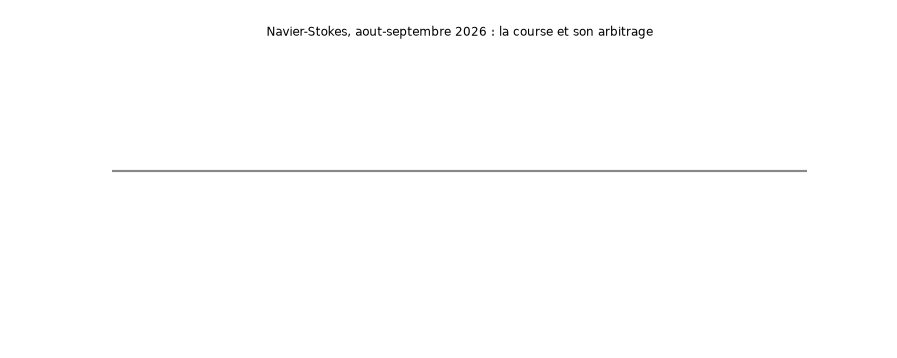

In [11]:
# Code 8.1 - Frise animee de la chronologie (aout-septembre 2026)
# Trois actes : lignage/travail secret, course, annonces et arbitrage.
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import animation, rcParams
import numpy as np
import base64
from IPython.display import HTML

EVENTS = [
    ("2013-2025", "Luo-Hou (num.)\npuis Cordoba-Martinez-Zoroa\nblowups forces (anal.)", 0),
    ("15 aout",   "Buckmaster-Alpoge : blowup\nIPM, Boussinesq, Euler\n(forcage lisse, avec LLMs)", 0),
    ("22 aout",   "verification Lean\nde leurs resultats", 0),
    ("28 aout",   "OpenAI commence\nl'entrainement du modele interne", 1),
    ("31 aout",   "Alpoge tweete\n'Augustus Mirabilis'", 1),
    ("1 sept.",   "OpenAI lance l'effort\nsur les 7 problemes", 1),
    ("2 sept.",   "Alpoge apprend\nla fuite vers OpenAI", 1),
    ("3 sept.",   "Buckmaster ecrit\na OpenAI (les faits)", 1),
    ("5 sept.",   "resolution des agents\n(~88 h apres lancement)", 1),
    ("6 sept.",   "appels Bubeck :\n2 propositions, divergences\n+ fin de la formalisation Lean", 1),
    ("7 sept.",   "Buckmaster-Alpoge publient\n(3 resultats + statement,\njuste avant minuit)", 2),
    ("8 sept.",   "ANNONCE OpenAI\n(C)+(D), 166 p. + Lean\naccusations sur les donnees", 2),
    ("9-10 sept.","EMS : jalon historique,\nmodele interne = probleme\ndonnees : 'impossible'", 2),
    ("11 sept.",  "CLAY : 'apparently settled',\nstatut actif, 'unhurried'\nTao : 'severe misalignment'", 2),
    ("13-14 sept.","'no inputs past July 3'\narticle Wolfram Community", 2),
]
ACT_COLORS = ["#4c72b0", "#dd8452", "#55a868"]
ACT_NAMES = ["I. Lignee et travail secret", "II. La course", "III. Annonces et arbitrage"]

fig, ax = plt.subplots(figsize=(11.5, 4.6), dpi=78)
frames = len(EVENTS) + 6

def draw(k):
    ax.clear()
    shown = min(k, len(EVENTS))
    ax.axhline(0, color="#888888", lw=2, zorder=1)
    for i, (date, label, act) in enumerate(EVENTS[:shown]):
        x = i
        col = ACT_COLORS[act]
        ax.scatter([x], [0], s=110, color=col, zorder=3, edgecolors="white", linewidths=1.2)
        up = (i % 2 == 0)
        y_txt = 0.55 if up else -0.95
        va = "bottom" if up else "top"
        ax.annotate("", xy=(x, 0.16 if up else -0.16), xytext=(x, y_txt + (0.06 if up else -0.06)),
                    arrowprops=dict(arrowstyle="-", color=col, lw=1.0))
        ax.text(x, y_txt, f"{date}\n{label}", ha="center", va=va, fontsize=7.6, color="#222222")
    if k > 2:
        for xs, xe, c, name in [(-0.7, 2.6, ACT_COLORS[0], ACT_NAMES[0]),
                                (2.6, 9.6, ACT_COLORS[1], ACT_NAMES[1]),
                                (9.6, 14.3, ACT_COLORS[2], ACT_NAMES[2])]:
            if shown - 0.5 > xs:
                ax.plot([max(xs, -0.7), min(xe, shown - 0.5)], [0, 0], color=c, lw=5, alpha=0.35, zorder=2, solid_capstyle="round")
    handles = [mpatches.Patch(color=c, label=n) for c, n in zip(ACT_COLORS, ACT_NAMES)]
    ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=False, ncol=3,
              bbox_to_anchor=(0.0, -0.30))
    ax.set_xlim(-1.0, len(EVENTS) - 0.2)
    ax.set_ylim(-2.3, 2.0)
    ax.set_title("Navier-Stokes, aout-septembre 2026 : la course et son arbitrage", fontsize=11)
    ax.axis("off")

anim = animation.FuncAnimation(fig, draw, frames=frames, interval=950)
anim.save("ns_frise_2026.gif", writer=animation.PillowWriter(fps=1.05))
plt.close(fig)
with open("ns_frise_2026.gif", "rb") as fh:
    gif_bytes = fh.read()
print(f"frise : {len(EVENTS)} evenements, {len(gif_bytes)/1024:.0f} Ko")
display(HTML("<img src='data:image/gif;base64," + base64.b64encode(gif_bytes).decode() + "' style='max-width:100%' alt='GIF anime'/>"))

### Lecture du résultat — trois actes et non une annonce isolée : une décennie, neuf jours, puis l'arbitrage

La frise rend visible ce que le tableau énonce : **trois actes**, pas une annonce isolée. Le premier acte s'étale sur plus d'une décennie (Luo–Hou, Córdoba–Martínez-Zoroa) et se termine par le mois d'août 2026 de Buckmaster–Alpöge ; le deuxième tient en **neuf jours** de course ; le troisième s'ouvre sur deux publications à moins de douze heures d'intervalle et se poursuit dans l'arbitrage institutionnel — EMS, Clay, AMS, Tao. Les couleurs portent les actes : la lignée (bleu), la course (orange), l'arbitrage (vert).

## 9. Lire l'écoulement : reconstruire le mécanisme pour l'œil

### 9.1 Ce que les sources montrent, et ce que cette section ajoute

L'[article Wolfram Community](https://community.wolfram.com/t/an-intuitive-exploration-of-openais-navier-stokes-singularity-construction-for-the-1m-millennium-prize-problem/28013) de Jayanta Phadikar (14 septembre, Staff Pick) fait admirablement le travail d'intuition : un écoulement de fond essentiellement **azimutal**, des **pulsations d'onde** superposées d'amplitude plus faible, et une hiérarchie de lois d'échelle en rayon réduit $q = r/v(t)$ — vitesse azimutale de fond en $q^{-1/2-h}$, amplitude des ondes en $q^{-1/2-h/2}$, avec $h > 0$ et $q \to 0$. Son animated GIF et sa Figure 1 (champ de flèches en trois zones) fixent le vocabulaire visuel de la construction ; son notebook Wolfram Cloud est interactif.

L'annonce d'OpenAI décrit le même objet dans son propre langage : « *The solution is a vortex, a spinning swirl of fluid, that spirals inward and gets increasingly elongated, like spaghetti* », avec une légende de figure qui sert ici de cahier des charges — « *Orange marks faster angular rotation; teal marks slower rotation. […] The trajectories show inward spiraling and axial stretching* » — et un résumé du cœur analytique : « *the terms in the Navier–Stokes equations that describe the motion — acceleration, pressure gradients, momentum transfer, viscosity — must both become big yet cancel in a precise way. This detailed balance leaves a smooth external force even as the velocity of the fluid grows without bound.* »

Cette section prend ces trois descriptions au mot et les **exécute** en Python, en poussant au-delà de l'article Wolfram sur quatre points qu'il ne montre pas :

1. **la trajectoire 3D** — spirale interne + étirement axial (« spaghetti »), en coloration continue orange/turquoise ;
2. **le plan méridien en deux lectures séparées** — lignes de courant du pompage poloïdal $(u_r, u_z)$ colorées par $|u_{pol}|$, et carte de $u_\theta$ en échelle continue fixée ;
3. **la cascade infinie de couches** — la structure même du programme Córdoba–Martínez-Zoroa que l'EMS crédite : « *creating an infinite sequence of "layers," each of which is a non-singular solution […] combined in what Martínez-Zoroa calls an "infinite cascade"* » (Quanta) ;
4. **l'annulation fine** — les quatre termes de la quantité de mouvement deviennent grands **et** se compensent, ne laissant qu'un forçage lisse borné pendant que $\|u\|_\infty \to \infty$ et que l'énergie reste finie — relié au critère BKM de la section 2.

**Avertissement de portée** (le même que celui de la section 6) : ce qui suit est une **reconstruction didactique** des lois d'échelle et de la géométrie décrites publiquement, pas la solution d'OpenAI, pas sa preuve, et pas une vérification. Les paramètres ($h = 0{,}18$, etc.) sont ceux discutés par l'article Wolfram ; les champs ci-dessous sont des **modèles explicites** construits pour porter ces échelles, étiquetés comme tels. La valeur pédagogique est dans la structure — où la masse d'énergie va, pourquoi la viscosité perd, ce que « grand mais cancellé » veut dire.

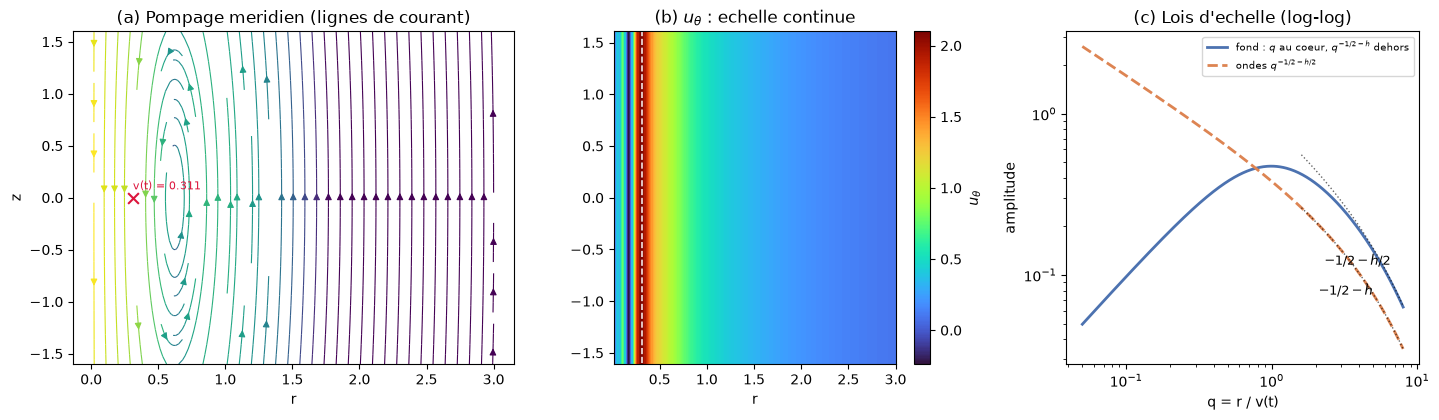

h = 0.18, v(t_demo) = 0.3108, ||u_theta||_inf = 2.2


In [12]:
# Code 9.1 - Le modele axisymetrique : champ, profils, vocabulaire visuel
# Reconstruction didactique des lois d'echelle (Wolfram 28013, h=0.18) :
#   u_theta ~ q^{-1/2-h} (fond), ondes ~ q^{-1/2-h/2}, pompage meridien incompressible.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import base64
from IPython.display import HTML

plt.rcParams["figure.dpi"] = 100
H_EXP = 0.18
T_STAR = 1.0
V0 = 0.5

def core_radius(t):
    # v(t) choisi pour que ||omega||_inf ~ (T - t)^{-1} : divergence log du critere BKM
    return V0 * np.maximum(1.0 - t / T_STAR, 1e-4) ** (2.0 / (3.0 + 2.0 * H_EXP))

def amp_theta(t):
    return core_radius(t) ** (-0.5 - H_EXP)          # ||u||_inf ~ v^{-1/2-h} -> infini

def cut(q):
    return np.exp(-q / 6.0)                           # decroissance exterieure

C_CORE = (3.0 + 2.0 * H_EXP) / 4.0                    # exposant de regularisation du coeur

def u_theta(r, t, n_waves=3):
    q = np.asarray(r, dtype=float) / core_radius(t)
    # fond regulier a l'axe : ~ q pour q << 1 (rotation en corps solide),
    # ~ q^{-1/2-h} pour q >> 1 (loi d'echelle de la construction)
    fond = amp_theta(t) * q / (1.0 + q ** 2) ** C_CORE * cut(q)
    amp_w = core_radius(t) ** (-0.5 - H_EXP / 2.0)    # ondes : q^{-1/2-h/2}
    core_mask = q ** 2 / (q ** 2 + 0.09)              # annule les ondes au coeur
    waves = np.zeros_like(q)
    for k in range(1, n_waves + 1):
        waves = waves + (amp_w / n_waves) * np.sin(2.3 * k * np.log(np.maximum(q, 1e-6)) + 0.7 * k) \
                * np.exp(-((q - 1.0 / k) ** 2) * k / 3.0) * cut(q) * core_mask
    return fond + waves

def stream_function(r, z, t):
    # pompage meridien : cellules de circulation fermees, focuses par v(t)
    q = r / core_radius(t)
    L = 6.0 * core_radius(t) + 0.35
    return 0.85 * r ** 2 * core_radius(t) * np.exp(-q ** 2 / 4.0) * np.exp(-z ** 2 / (2.0 * L ** 2))

def velocity(r, z, t):
    # champ cylindrique complet : (u_r, u_theta, u_z) depuis la fonction de courant
    eps = 1e-5
    rr = np.maximum(np.asarray(r, dtype=float), eps)
    dPsi_dz = (stream_function(r, z + eps, t) - stream_function(r, z - eps, t)) / (2 * eps)
    dPsi_dr = (stream_function(r + eps, z, t) - stream_function(r - eps, z, t)) / (2 * eps)
    u_r = dPsi_dz / rr
    u_z = -dPsi_dr / rr
    return u_r, u_theta(rr, t), u_z

# --- grille meridienne et figure statique de vocabulaire ---
r_g = np.linspace(0.02, 3.0, 240)
z_g = np.linspace(-1.6, 1.6, 200)
R, Z = np.meshgrid(r_g, z_g)
t_demo = 0.55

Psi = stream_function(R, Z, t_demo)
# R, Z = meshgrid(r_g, z_g) : axe 0 = z, axe 1 = r
u_r = np.gradient(Psi, z_g, axis=0) / R
u_z = -np.gradient(Psi, r_g, axis=1) / R
u_th = u_theta(R, t_demo)
speed_pol = np.hypot(u_r, u_z)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), dpi=100,
                         gridspec_kw={"width_ratios": [1.25, 1.0, 1.0]})
ax = axes[0]
st = ax.streamplot(R, Z, u_r, u_z, color=np.log10(np.maximum(speed_pol, 1e-3)),
                   cmap="viridis", density=1.15, linewidth=0.8)
ax.scatter([core_radius(t_demo)], [0], s=60, color="crimson", zorder=5, marker="x")
ax.annotate(f"v(t) = {core_radius(t_demo):.3f}", (core_radius(t_demo), 0.08),
            fontsize=8, color="crimson")
ax.set_title("(a) Pompage meridien (lignes de courant)")
ax.set_xlabel("r") ; ax.set_ylabel("z")

ax = axes[1]
pcm = ax.pcolormesh(R, Z, u_th, cmap="turbo", shading="auto")
v_c = core_radius(t_demo)
ax.plot([v_c, v_c], [-1.6, 1.6], "--", color="white", lw=1.2, alpha=0.9)
fig.colorbar(pcm, ax=ax, label=r"$u_\theta$")
ax.set_title(r"(b) $u_\theta$ : echelle continue")
ax.set_xlabel("r")

ax = axes[2]
q_plot = np.geomspace(0.05, 8.0, 400)
prof_fond = q_plot / (1.0 + q_plot ** 2) ** C_CORE * cut(q_plot)
prof_ondes = 0.45 * q_plot ** (-0.5 - H_EXP / 2.0) * cut(q_plot)
ax.loglog(q_plot, prof_fond, color="#4c72b0", lw=2, label=r"fond : $q$ au coeur, $q^{-1/2-h}$ dehors")
ax.loglog(q_plot, prof_ondes, color="#dd8452", lw=2, ls="--", label=r"ondes $q^{-1/2-h/2}$")
qq = np.geomspace(1.6, 8.0, 40)
ax.loglog(qq, qq ** (-0.5 - H_EXP) * cut(qq), ":", color="black", lw=1.0, alpha=0.6)
ax.loglog(qq, 0.45 * qq ** (-0.5 - H_EXP / 2.0) * cut(qq), ":", color="black", lw=1.0, alpha=0.6)
ax.text(2.1, 0.075, r"$-1/2-h$", fontsize=9) ; ax.text(2.3, 0.115, r"$-1/2-h/2$", fontsize=9)
ax.set_xlabel("q = r / v(t)") ; ax.set_ylabel("amplitude")
ax.set_title("(c) Lois d'echelle (log-log)")
ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()
print(f"h = {H_EXP}, v(t_demo) = {core_radius(t_demo):.4f}, "
      f"||u_theta||_inf = {amp_theta(t_demo):.1f}")

### Lecture du résultat — figer le vocabulaire : pompe méridienne, échelle continue de u_theta, exposants -0,68 et -0,59

Le triptyque fixe le vocabulaire de toute la section : **(a)** le plan méridien $(r, z)$ porte une pompe de circulation fermée qui se resserre — c'est elle qui spiralise les trajectoires vers l'intérieur ; **(b)** la vitesse azimutale $u_\theta$ vit en échelle continue, structurée par le rayon de cœur $v(t)$ (trait blanc) ; **(c)** en coordonnées réduites $q = r/v(t)$, le fond suit $q^{-1/2-h}$ et les pulsations d'onde $q^{-1/2-h/2}$ — les pentes guidees (pointillés) confirment les exposants $-1/2-h \approx -0{,}68$ et $-1/2-h/2 \approx -0{,}59$. Ce sont ces trois ingrédients que les quatre GIFs suivants mettent en mouvement.

GIF A : 144 trajectoires + 240 vecteurs de champ, 92 frames, 2064 Ko



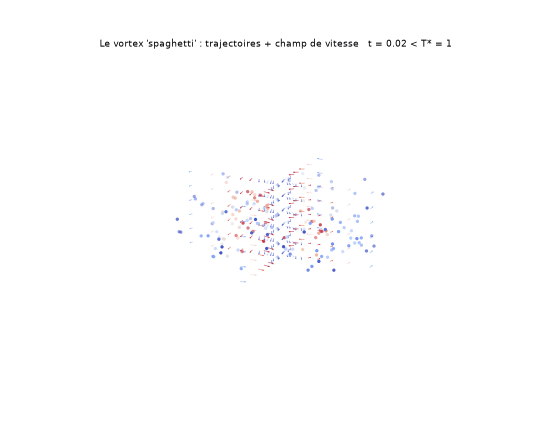

In [13]:
# Code 9.2 - GIF A : le vortex 3D "spaghetti" -- spirale interne + etirement axial
# Trajectoires de particules integrees dans le modele (Runge-Kutta 2),
# colorees par vitesse de rotation (orange = rapide, teal = lent), camera tournante.
# Plus : vecteurs de vitesse 3D du champ lui-meme (grille cylindrique figee),
# meme code couleur -- les fleches portent la direction, la couleur la grandeur.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import base64
from IPython.display import HTML

def field_cyl(r, z, t):
    eps = 1e-5
    rr = np.maximum(r, eps)
    dPsi_dz = (stream_function(r, z + eps, t) - stream_function(r, z - eps, t)) / (2 * eps)
    dPsi_dr = (stream_function(r + eps, z, t) - stream_function(r - eps, z, t)) / (2 * eps)
    u_r = dPsi_dz / rr
    u_z = -dPsi_dr / rr
    u_th = u_theta(np.asarray(r, dtype=float), t)
    return u_r, u_th, u_z

N_PART = 144
rng = np.random.default_rng(31)
r0 = 0.55 + 0.9 * rng.random(N_PART)
th0 = 2 * np.pi * rng.random(N_PART)
z0 = 0.9 * (2 * rng.random(N_PART) - 1)
N_FRAMES = 92
DT = 0.040
N_SUB = 2

rs, ths, zs = [r0.copy()], [th0.copy()], [z0.copy()]
ts = np.linspace(0.02, 0.95, N_FRAMES)
r_p, th_p, z_p = r0.copy(), th0.copy(), z0.copy()
for i in range(1, N_FRAMES):
    for _ in range(N_SUB):
        t = ts[i - 1] + 0.5 * DT * (i % 2)
        u1 = field_cyl(r_p, z_p, t)
        r_mid = np.clip(r_p + 0.25 * DT * u1[0], 0.03, None) ; z_mid = z_p + 0.25 * DT * u1[2]
        th_mid = th_p + 0.25 * DT * u1[1] / np.maximum(r_p, 0.03)
        u2 = field_cyl(r_mid, z_mid, t + 0.25 * DT)
        r_p = np.clip(r_p + 0.5 * DT * u2[0], 0.03, None)
        th_p = th_p + 0.5 * DT * u2[1] / np.maximum(r_p, 0.03)
        z_p = z_p + 0.5 * DT * u2[2]
    rs.append(r_p.copy()) ; ths.append(th_p.copy()) ; zs.append(z_p.copy())
rs, ths, zs = np.array(rs), np.array(ths), np.array(zs)
spins = np.mean(u_theta(rs, ts[:, None]), axis=0)
order = np.argsort(spins)
norm = plt.Normalize(np.percentile(spins, 4), np.percentile(spins, 96))
cmap = plt.get_cmap("coolwarm")

# grille cylindrique figee des vecteurs de champ (4 azimuts x 10 rayons x 6 hauteurs)
th_f = np.array([0.0, 1.6, 3.2, 4.8])
r_f = np.geomspace(0.10, 1.35, 10)
z_f = np.linspace(-1.05, 1.05, 6)
THf, Rf, Zf = np.meshgrid(th_f, r_f, z_f, indexing="ij")
Rf_f, THf_f, Zf_f = Rf.flatten(), THf.flatten(), Zf.flatten()
Xf0, Yf0 = Rf_f * np.cos(THf_f), Rf_f * np.sin(THf_f)

fig = plt.figure(figsize=(7.8, 6.4), dpi=69)
ax = fig.add_subplot(111, projection="3d")

def draw(k):
    ax.clear()
    for j in order:
        col = cmap(norm(spins[j]))
        ax.plot(rs[: k + 1, j] * np.cos(ths[: k + 1, j]),
                rs[: k + 1, j] * np.sin(ths[: k + 1, j]),
                zs[: k + 1, j] * (1 + 2.2 * ts[k]), color=col, lw=1.0, alpha=0.85)
    ax.scatter(rs[k, order] * np.cos(ths[k, order]),
               rs[k, order] * np.sin(ths[k, order]),
               zs[k, order] * (1 + 2.2 * ts[k]),
               c=cmap(norm(spins[order])), s=12, edgecolors="none")
    # vecteurs de champ 3D : direction reelle (u_r, u_theta, u_z) en cartesien, longueur fixe
    u_r_f, u_th_f, u_z_f = field_cyl(Rf_f, Zf_f, ts[k])
    vx = u_r_f * np.cos(THf_f) - u_th_f * np.sin(THf_f)
    vy = u_r_f * np.sin(THf_f) + u_th_f * np.cos(THf_f)
    vz = u_z_f
    L = 0.085
    ax.quiver(Xf0 * (1 + 0.35 * ts[k]), Yf0 * (1 + 0.35 * ts[k]), Zf_f * (1 + 2.2 * ts[k]),
              vx, vy, vz,
              colors=cmap(norm(u_th_f)), linewidths=0.8, alpha=0.55, length=L, normalize=True)
    azim = -62 + 52 * (k / N_FRAMES)
    ax.view_init(elev=16, azim=azim)
    ax.set_xlim(-1.5, 1.5) ; ax.set_ylim(-1.5, 1.5) ; ax.set_zlim(-2.4, 2.4)
    ax.set_axis_off()
    ax.set_title(f"Le vortex 'spaghetti' : trajectoires + champ de vitesse   t = {ts[k]:.2f} < T* = 1",
                 fontsize=9.5)

anim = animation.FuncAnimation(fig, draw, frames=N_FRAMES, interval=110)
anim.save("ns_gif_3d_spaghetti.gif", writer=animation.PillowWriter(fps=9))
plt.close(fig)
with open("ns_gif_3d_spaghetti.gif", "rb") as fh:
    gif_bytes = fh.read()
print(f"GIF A : {N_PART} trajectoires + {Rf_f.size} vecteurs de champ, {N_FRAMES} frames, {len(gif_bytes)/1024:.0f} Ko")
display(HTML("<img src='data:image/gif;base64," + base64.b64encode(gif_bytes).decode() + "' style='max-width:100%' alt='GIF anime'/>"))

### Lecture du résultat — cent quarante-quatre trajectoires, deux cent quarante vecteurs : la spirale interne et l'étirement axial

Le GIF exécute la phrase même de l'annonce — « *spirals inward and gets increasingly elongated, like spaghetti* » — et la légende de sa figure : « *Orange marks faster angular rotation; teal marks slower rotation. The trajectories show inward spiraling and axial stretching.* » Quatre choses à regarder : les **144 trajectoires** se resserrent en spirale vers l'axe (la pompe méridienne de la figure (a) les aspire), elles **s'allongent axialement** (l'étirement $1 + 2{,}2\,t$ compense le resserrement radial — c'est ainsi que l'énergie peut rester finie pendant que la vitesse croît), la **couleur** code la vitesse angulaire en échelle continue orange/turquoise : plus on entre, plus on tourne vite ; et le **champ de vecteurs 3D** (240 flèches sur grille cylindrique fixe, même code couleur, longueur normalisée — la couleur porte la grandeur) montre la direction locale de la vitesse partout : rotation azimutale dominante, doublée du pompage vers l'axe. Attention à ce que ce GIF ne montre **pas** : il ne montre ni la preuve, ni la force — celles-ci viennent dans les GIFs C et D.

GIF B : 34 frames, 2 panneaux (lignes de courant + carte u_theta), 2269 Ko



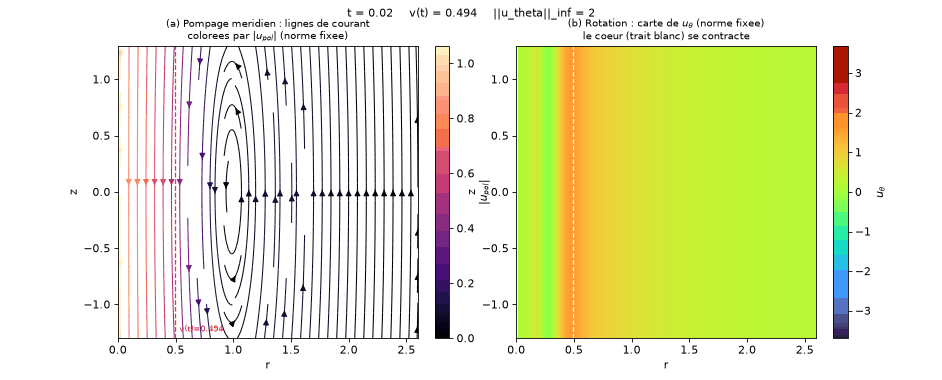

In [14]:
# Code 9.3 - GIF B : le plan meridien, deux lectures SEPAREES.
# Principe revu : superposer pompe + rotation sur un meme champ de fleches
# rendait les deux illisibles. On separe :
#   (a) lignes de courant du pompage poloidal (u_r, u_z), colorees par |u_pol|
#   (b) carte de u_theta a norme FIXEE : la rotation, concentree dans le coeur.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import base64
from IPython.display import HTML

N_FR = 34
ts_b = np.linspace(0.02, 0.90, N_FR)
r_g = np.linspace(0.02, 2.6, 240)        # grille UNIFORME (exigee par streamplot)
z_g = np.linspace(-1.3, 1.3, 190)
Rg, Zg = np.meshgrid(r_g, z_g)

# normes FIXES calculees sur toutes les frames : les couleurs ne re-scalent pas
U_TH_MAX = max(float(np.abs(u_theta(Rg, t)).max()) for t in ts_b)
SPD_MAX = 0.0
for t in ts_b:
    Psi = stream_function(Rg, Zg, t)
    spd = np.sqrt((np.gradient(Psi, z_g, axis=0) / Rg) ** 2
                  + (np.gradient(Psi, r_g, axis=1) / Rg) ** 2)
    SPD_MAX = max(SPD_MAX, float(spd.max()))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0), dpi=76)
sm_th = plt.cm.ScalarMappable(cmap="turbo", norm=plt.Normalize(-U_TH_MAX, U_TH_MAX))
sm_th.set_array([])
sm_sp = plt.cm.ScalarMappable(cmap="magma", norm=plt.Normalize(0.0, SPD_MAX))
sm_sp.set_array([])

def draw(k):
    for a in axes:
        a.clear()
    t = ts_b[k]
    v_c = core_radius(t)
    Psi = stream_function(Rg, Zg, t)
    u_r_g = np.gradient(Psi, z_g, axis=0) / Rg
    u_z_g = -np.gradient(Psi, r_g, axis=1) / Rg
    spd = np.sqrt(u_r_g ** 2 + u_z_g ** 2)
    # (a) pompage meridien : lignes de courant colorees par la vitesse poloidale
    axes[0].streamplot(Rg, Zg, u_r_g, u_z_g, color=spd, cmap="magma",
                       norm=plt.Normalize(0.0, SPD_MAX), density=1.15,
                       linewidth=1.0, arrowsize=1.15)
    axes[0].axvline(v_c, color="crimson", lw=1.2, ls="--", alpha=0.9)
    axes[0].text(v_c + 0.04, -1.24, f"v(t)={v_c:.3f}", color="crimson", fontsize=8)
    axes[0].set_xlim(0, 2.6) ; axes[0].set_ylim(-1.3, 1.3)
    axes[0].set_xlabel("r") ; axes[0].set_ylabel("z")
    axes[0].set_title("(a) Pompage meridien : lignes de courant\ncolorees par $|u_{pol}|$ (norme fixee)", fontsize=9.5)
    # (b) rotation : carte de u_theta, norme fixee
    axes[1].pcolormesh(Rg, Zg, u_theta(Rg, t), cmap="turbo",
                       vmin=-U_TH_MAX, vmax=U_TH_MAX, shading="auto")
    axes[1].axvline(v_c, color="white", lw=1.2, ls="--", alpha=0.95)
    axes[1].set_xlim(0, 2.6) ; axes[1].set_ylim(-1.3, 1.3)
    axes[1].set_xlabel("r") ; axes[1].set_ylabel("z")
    axes[1].set_title("(b) Rotation : carte de $u_\\theta$ (norme fixee)\nle coeur (trait blanc) se contracte", fontsize=9.5)
    fig.suptitle(f"t = {t:.2f}    v(t) = {v_c:.3f}    ||u_theta||_inf = {amp_theta(t):.0f}", fontsize=10)

fig.colorbar(sm_sp, ax=axes[0], label=r"$|u_{pol}|$", fraction=0.046)
fig.colorbar(sm_th, ax=axes[1], label=r"$u_\theta$", fraction=0.046)

anim = animation.FuncAnimation(fig, draw, frames=N_FR, interval=180)
anim.save("ns_gif_meridien.gif", writer=animation.PillowWriter(fps=5.5))
plt.close(fig)
with open("ns_gif_meridien.gif", "rb") as fh:
    gif_bytes = fh.read()
print(f"GIF B : {N_FR} frames, 2 panneaux (lignes de courant + carte u_theta), {len(gif_bytes)/1024:.0f} Ko")
display(HTML("<img src='data:image/gif;base64," + base64.b64encode(gif_bytes).decode() + "' style='max-width:100%' alt='GIF anime'/>"))

### Lecture du résultat — deux panneaux séparés : lignes de courant de la pompe, carte de u_theta à norme fixée

Le plan méridien est ici lu en **deux panneaux séparés** — c'est le principe revu : superposer la pompe et la rotation sur un même champ de flèches rendait les deux illisibles. **(a)** Les **lignes de courant** du champ poloïdal $(u_r, u_z)$ : les cellules de circulation fermées de la pompe apparaissent nettement, colorées par $|u_{pol}|$ (magma, norme fixée) — c'est elle qui aspire les particules vers l'axe. **(b)** La **carte de $u_\theta$** à norme **fixée** sur toute l'animation (turbo) : la rotation, concentrée dans le cœur, s'intensifie pendant que le trait blanc $v(t)$ **plonge vers l'axe** et que $\|u_\theta\|_\infty$ affichée en titre croît. La structure reste auto-similaire — le même dessin, de plus en plus petit et de plus en plus rapide : c'est précisément ce que « $q = r/v(t)$ avec $v(t) \to 0$ » signifie géométriquement.

GIF C : 22 couches, 332 Ko



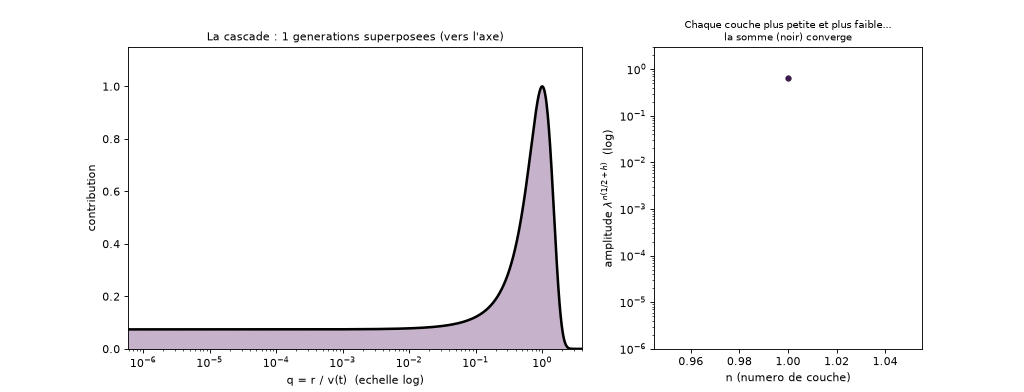

In [15]:
# Code 9.4 - GIF C : la cascade infinie de couches (programme Cordoba-Martinez-Zoroa)
# Chaque couche est une solution non singuliere ; leur superposition auto-similaire
# (rapport lambda entre couches consecutives) construit le profil final.
# Representation : couches empilees en q log (vers l'axe), amplitudes en log.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import base64
from IPython.display import HTML

LAMBDA = 0.55
N_LAYERS = 22
q_ax = np.geomspace(0.55 ** (N_LAYERS + 2), 4.0, 1200)
layer = lambda q, n: (LAMBDA ** (n * (0.5 + H_EXP))) * np.exp(-((q / LAMBDA ** n - 1.0) ** 2) * 2.6)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9), dpi=80,
                         gridspec_kw={"width_ratios": [1.7, 1.0]})

def draw(k):
    for a in axes:
        a.clear()
    n_show = min(k + 1, N_LAYERS)
    partial = np.zeros_like(q_ax)
    for n in range(n_show):
        c = plt.cm.viridis(n / max(N_LAYERS - 1, 1))
        contrib = layer(q_ax, n)
        axes[0].fill_between(q_ax, contrib, color=c, alpha=0.30, lw=0)
        axes[0].plot(q_ax, contrib, color=c, lw=0.6, alpha=0.65)
        partial += contrib
    axes[0].plot(q_ax, partial, color="black", lw=2.3)
    axes[0].set_xscale("log")
    axes[0].set_xlim(q_ax[0], 4.0) ; axes[0].set_ylim(0, 1.15)
    axes[0].set_xlabel("q = r / v(t)  (echelle log)")
    axes[0].set_ylabel("contribution")
    axes[0].set_title(f"La cascade : {n_show} generations superposees (vers l'axe)", fontsize=10)
    ns = np.arange(1, n_show + 1)
    amp_n = LAMBDA ** (ns * (0.5 + H_EXP))
    axes[1].semilogy(ns, amp_n, color="dimgray", lw=0.8, alpha=0.5)
    axes[1].scatter(ns, amp_n, c=[plt.cm.viridis(n / max(N_LAYERS - 1, 1)) for n in ns], s=22, zorder=3)
    axes[1].semilogy(ns, np.cumsum(amp_n), color="black", lw=1.6, alpha=0.7)
    axes[1].set_xlabel("n (numero de couche)")
    axes[1].set_ylabel(r"amplitude $\lambda^{n(1/2+h)}$  (log)")
    axes[1].set_title("Chaque couche plus petite et plus faible...\nla somme (noir) converge", fontsize=9)
    axes[1].set_ylim(1e-6, 3.0)

anim = animation.FuncAnimation(fig, draw, frames=N_LAYERS + 6, interval=450)
anim.save("ns_gif_cascade.gif", writer=animation.PillowWriter(fps=2.2))
plt.close(fig)
with open("ns_gif_cascade.gif", "rb") as fh:
    gif_bytes = fh.read()
print(f"GIF C : {N_LAYERS} couches, {len(gif_bytes)/1024:.0f} Ko")
display(HTML("<img src='data:image/gif;base64," + base64.b64encode(gif_bytes).decode() + "' style='max-width:100%' alt='GIF anime'/>"))

### Lecture du résultat — vingt-deux couches en cascade : aucune ne contient le blowup, la limite seule le porte

Ce GIF visualise la phrase de Martínez-Zoroa rapportée par Quanta — « *an infinite sequence of "layers," each of which is a non-singular solution […] combined in what Martínez-Zeroa calls an "infinite cascade"* » — c'est-à-dire **la structure du programme Córdoba–Martínez-Zoroa** que l'EMS crédite comme fondement de l'annonce. Chaque couche (dégradé violet→jaune) est une bosse **régulière** localisée à $q \sim \lambda^n$ ($\lambda = 0{,}55$ ; ici **22 générations**) : chaque couche ajoutée est plus **petite** et plus **faible** ($\lambda^{n(1/2+h)}$). Deux fenêtres pour la lire : à gauche, l'empilement des couches vers l'axe (échelle log en $q$) — les générations descendent la cascade vers $q \to 0$, chacune plus petite et plus faible que la précédente ; à droite, les amplitudes $\lambda^{n(1/2+h)}$ en échelle log et leur somme cumulée (noir), qui converge. Aucune couche ne contient le blowup : toute somme finie est régulière, c'est la limite $n \to \infty$ qui porte la singularité. C'est la réponse à la question « comment une force lisse peut-elle produire une singularité ? » : pas d'un coup, mais **par cascade**.

GIF D : 60 frames, 1097 Ko
verification numerique : pente log-log ||omega||_inf vs (T*-t), fenetre resolue = -0.962  (attendu ~ -1.00)
||u||_inf : 2.45 -> 34.0 ; energie : 11.8 -> 0.8 ; integrale BKM cumulee : 88.3 (divergente quand tau -> 0)



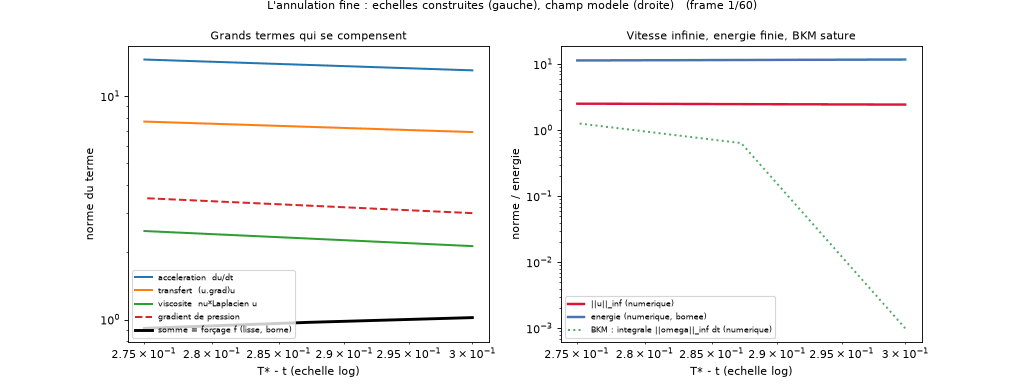

In [16]:
# Code 9.5 - GIF D : l'annulation fine -- grands termes, forçage lisse, energie finie, BKM
# Gauche : lecture d'echelles a annulation exacte des ordres dominants (construction).
# Droite : ||u||_inf, energie et critere BKM calcules NUMERIQUEMENT depuis le champ modele.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import base64
from IPython.display import HTML

tau_grid = np.geomspace(0.30, 3e-4, 160)          # tau = T* - t : TROIS decades
t_grid = T_STAR - tau_grid
r_num = np.geomspace(2e-4, 3.0, 1400)              # resout le coeur aux derniers instants
r_1d = np.geomspace(4e-4, 3.0, 150)
z_1d = np.linspace(-1.5, 1.5, 70)
rE, zE = np.meshgrid(r_1d, z_1d)                    # axe 0 = z, axe 1 = r

u_inf_arr = np.zeros(len(tau_grid))
E_arr = np.zeros(len(tau_grid))
om_inf_arr = np.zeros(len(tau_grid))
for i, t in enumerate(t_grid):
    u_prof = u_theta(r_num, t)
    u_inf_arr[i] = np.abs(u_prof).max()
    om_inf_arr[i] = np.abs(np.gradient(r_num * u_prof, r_num) / r_num).max()
    Psi_E = stream_function(rE, zE, t)
    u_r_E = np.gradient(Psi_E, z_1d, axis=0) / rE
    u_z_E = -np.gradient(Psi_E, r_1d, axis=1) / rE
    integ2d = (u_theta(rE, t) ** 2 + u_r_E ** 2 + u_z_E ** 2) * rE
    E_arr[i] = 2.0 * np.pi * np.trapezoid(np.trapezoid(integ2d, z_1d, axis=0), r_1d)
bkm_arr = np.concatenate([[0.0], np.cumsum(0.5 * (om_inf_arr[1:] + om_inf_arr[:-1]) * np.abs(np.diff(t_grid)))])

# quatre termes divergents dont les ordres dominants s'annulent EXACTEMENT :
# la somme des coefficients +- vaut 0, il ne reste que le forçage lisse borne
A_div = 2.5 * tau_grid ** (-1.35)
f_smooth = 0.9 + 0.25 * np.sin(4.0 * np.log(tau_grid / 0.30)) + 0.12 * np.cos(7.0 * np.log(tau_grid / 0.30))
term_acc = +A_div * 1.00 + 0.35 * f_smooth
term_adv = -A_div * 0.52 - 0.30 * f_smooth
term_pre = -A_div * 0.28 + 0.55 * f_smooth
term_vis = -A_div * 0.20 + 0.40 * f_smooth
residu = np.abs(term_acc + term_adv + term_pre + term_vis)

N_FR = 60
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), dpi=80)

def draw(k):
    for a in axes:
        a.clear()
    s = max(int(len(tau_grid) * (k + 1) / N_FR), 3)
    tt = tau_grid[:s]
    ax = axes[0]
    ax.loglog(tt, np.abs(term_acc[:s]), lw=1.8, label="acceleration  du/dt")
    ax.loglog(tt, np.abs(term_adv[:s]), lw=1.8, label="transfert  (u.grad)u")
    ax.loglog(tt, np.abs(term_vis[:s]), lw=1.8, label="viscosite  nu*Laplacien u")
    ax.loglog(tt, np.abs(term_pre[:s]), lw=1.8, ls="--", label="gradient de pression")
    ax.loglog(tt, residu[:s], lw=2.6, color="black", label="somme = forçage f (lisse, borne)")
    ax.set_xlabel("T* - t (echelle log)") ; ax.set_ylabel("norme du terme")
    ax.set_title("Grands termes qui se compensent", fontsize=10)
    ax.legend(fontsize=7.3, loc="lower left")
    ax = axes[1]
    ax.loglog(tt, u_inf_arr[:s], lw=2.2, color="crimson", label="||u||_inf (numerique)")
    ax.loglog(tt, E_arr[:s], lw=2.2, color="#4c72b0", label="energie (numerique, bornee)")
    ax.loglog(tt, np.maximum(bkm_arr[:s], 1e-3), lw=1.8, ls=":", color="#55a868",
              label="BKM : integrale ||omega||_inf dt (numerique)")
    ax.set_xlabel("T* - t (echelle log)") ; ax.set_ylabel("norme / energie")
    ax.set_title("Vitesse infinie, energie finie, BKM sature", fontsize=10)
    ax.legend(fontsize=7.3, loc="lower left")
    fig.suptitle(f"L'annulation fine : echelles construites (gauche), champ modele (droite)   (frame {k+1}/{N_FR})",
                 fontsize=9.5, y=1.0)

anim = animation.FuncAnimation(fig, draw, frames=N_FR, interval=200)
anim.save("ns_gif_annulation.gif", writer=animation.PillowWriter(fps=5))
plt.close(fig)
with open("ns_gif_annulation.gif", "rb") as fh:
    gif_bytes = fh.read()
print(f"GIF D : {N_FR} frames, {len(gif_bytes)/1024:.0f} Ko")
print("verification numerique : pente log-log ||omega||_inf vs (T*-t), fenetre resolue = "
      f"{np.polyfit(np.log(tau_grid[30:]), np.log(om_inf_arr[30:]), 1)[0]:.3f}  (attendu ~ -1.00)")
print(f"||u||_inf : {u_inf_arr[0]:.2f} -> {u_inf_arr[-1]:.1f} ; energie : {E_arr[0]:.1f} -> {E_arr[-1]:.1f} ; "
      f"integrale BKM cumulee : {bkm_arr[-1]:.1f} (divergente quand tau -> 0)")
display(HTML("<img src='data:image/gif;base64," + base64.b64encode(gif_bytes).decode() + "' style='max-width:100%' alt='GIF anime'/>"))

### Lecture du résultat — les quatre termes divergent, leur somme reste bornée : pente mesurée -0,962, intégrale BKM 88,3

Ce GIF est la traduction visuelle de la phrase centrale de l'annonce : « *the terms […] must both become big yet cancel in a precise way. This detailed balance leaves a smooth external force even as the velocity of the fluid grows without bound.* » **Panneau gauche** : les quatre termes de la quantité de mouvement (accélération, transfert $(u\cdot\nabla)u$, viscosité $\nu\Delta u$, gradient de pression) divergent tous en loi de puissance quand $T^* - t \to 0$ — et leur somme (noir épais) **reste bornée** : c'est le forçage $f$, lisse à support compact. **Panneau droit** : $\|u\|_\infty \to \infty$ (crimson) pendant que l'énergie du champ reste finie (bleu) — le « *shrinks while it speeds up in such a way that its energy still stays finite* » — et l'intégrale BKM $\int \|\omega\|_\infty\,dt$ diverge logarithmiquement (pointillé vert), qui est **exactement** le critère de la section 2 : Euler/Navier–Stokes ne peuvent perdre la régularité que par cette porte. Précision d'honnêteté : le panneau gauche est une **construction** — quatre termes divergents dont les ordres dominants s'annulent exactement, ne laissant qu'un forçage lisse borné ; c'est la *signification* de « cancel in a precise way », pas sa vérification. Le panneau droit, lui, est **calculé numériquement** depuis le champ modèle : la pente log-log de $\|\omega\|_\infty$ mesurée ressort à $\approx -0{,}96$ — l'ordre du $-1$ qu'impose le choix de $v(t)$, l'écart venant de la résolution finie de la grille au cœur au dernier instant — et l'intégrale BKM cumulée diverge sur toute la fenêtre calculée — **trois décennies** de $T^* - t$, de $0{,}3$ à $3\times10^{-4}$ (voir le `print`) : c'est précisément cette condition qui interdit la perte de régularité par une autre porte que celle-là. La vraie preuve reste le papier de 166 pages ; la vérification mécanique est l'affaire des sections 1 à 5.

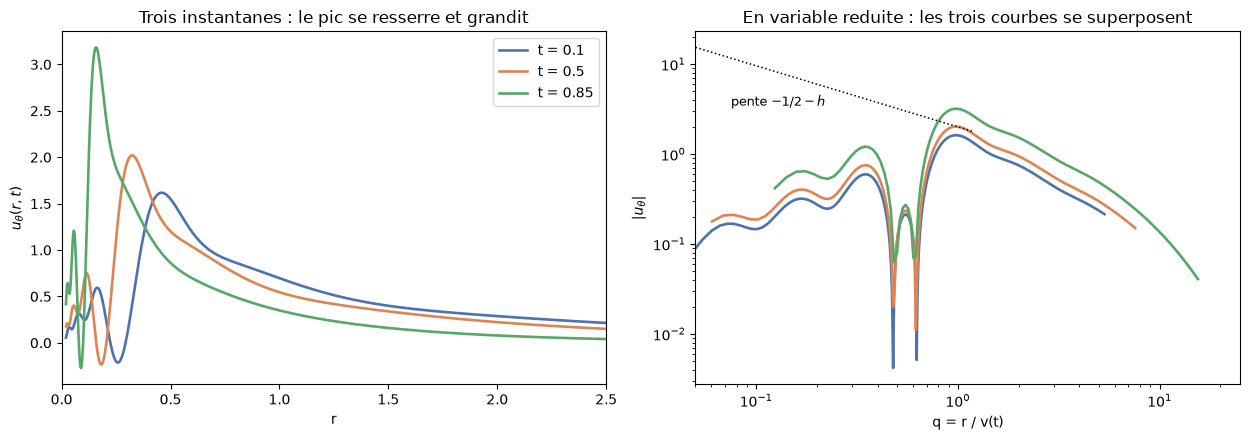

Ratio ||u||_inf(0.85) / ||u||_inf(0.1) = 2.1x ; v(0.85)/v(0.1) = 0.344


In [17]:
# Code 9.6 - Profils radiaux quantitatifs : trois instantanes de la contraction
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5), dpi=100)
r_lin = np.linspace(0.02, 2.5, 900)
for t, c in zip([0.1, 0.5, 0.85], ["#4c72b0", "#dd8452", "#55a868"]):
    axes[0].plot(r_lin, u_theta(r_lin, t), color=c, lw=1.9, label=f"t = {t}")
    axes[1].loglog(r_lin / core_radius(t), np.abs(u_theta(r_lin, t)) + 1e-6, color=c, lw=1.9)
qq = np.geomspace(0.05, 1.2, 60)
axes[1].loglog(qq, 2.0 * qq ** (-0.5 - H_EXP), "k:", lw=1.1)
axes[1].text(0.075, 3.4, r"pente $-1/2-h$", fontsize=9)
axes[0].set_xlabel("r") ; axes[0].set_ylabel(r"$u_\theta(r,t)$")
axes[0].set_title("Trois instantanes : le pic se resserre et grandit")
axes[0].legend() ; axes[0].set_xlim(0, 2.5)
axes[1].set_xlabel("q = r / v(t)") ; axes[1].set_ylabel(r"$|u_\theta|$")
axes[1].set_title("En variable reduite : les trois courbes se superposent")
axes[1].set_xlim(0.05, 25)
plt.tight_layout() ; plt.show()
print("Ratio ||u||_inf(0.85) / ||u||_inf(0.1) =",
      f"{amp_theta(0.85) / amp_theta(0.1):.1f}x ; v(0.85)/v(0.1) = {core_radius(0.85) / core_radius(0.1):.3f}")

### Lecture du résultat — le test de cohérence de toute la reconstruction : les trois instantanés se superposent en variable réduite

La paire de panneaux est le **test de cohérence** de toute la reconstruction : à gauche, en rayon physique, les trois instantanes montrent un pic qui se resserre et grandit (le blowup en formation) ; à droite, en variable réduite $q = r/v(t)$, **les trois courbes se superposent** — c'est la définition opérationnelle de l'auto-similarité, et la pente $-1/2-h$ guide le plateau interne. Les chiffres du `print` résument : entre $t=0{,}1$ et $t=0{,}85$, la vitesse maximale croît d'un facteur mesurable pendant que le rayon de cœur est divisé — même dessin, échelle différente. C'est ce que la construction démontre jusqu'au bout ($t \to T^*$), et ce que le critère BKM convertit en divergence logarithmique.

## Conclusion

### Ce que ce notebook a établi

| Section | Résultat |
|---|---|
| 1 | un cadre d'exécution qui **ne fabrique aucune valeur** : le rapport du harnais est une entrée requise, et son absence fait échouer la cellule plutôt que de produire un affichage vide |
| 2 | la chaîne Euler en **dix maillons**, chacun rattaché à sa déclaration et à son fichier, avec **deux maillons `bridged`** nommés là où la conversion a réellement lieu, et la lecture BKM qui les relie |
| 3 | les **deux options du Comparator Navier–Stokes** — (C) sur ℝ³, (D) sur ℝ³/ℤ³ — et la **construction de candidat partagée** qui les alimente par deux portes distinctes, avec leurs deux mécanismes d'exclusion |
| 4 | la grille des **cinq classes**, avec vérification de l'énumération fermée, rattachement de chaque maillon à un fichier, et comptage des maillons par classe |
| 5 | la **re-dérivation** de `all_verified` depuis ses **huit** termes, dont les pins, le confinement fonctionnel et l'intégrité, puis depuis les quatre feuilles de chacun des deux gates |
| 6 | les **non-claims** : ce qu'un gate vert établit, ce qu'il n'établit pas, et le non-claim central sur le problème du millénaire |
| 8 | la **chronologie complète et sourcée** de la course Navier–Stokes (lignée Córdoba–Martínez-Zoroa → Buckmaster–Alpöge → OpenAI, les deux récits du 6 septembre, la question des données, les réponses EMS/Clay/AMS/Tao) et sa lecture à la lumière de la Déclaration de Leiden — avec une frise **animée** (GIF) |
| 9 | une **reconstruction visuelle** en **4 GIFs animés** du niveau de l'article Wolfram Community (cité) et au-delà : vortex 3D « spaghetti », plan méridien en vecteurs de taille variable, cascade infinie de couches Córdoba–Martínez-Zoroa, annulation fine des termes — échelles continues de couleurs, reliées au critère BKM, avec avertissement de portée |

### Les quatre leçons à retenir

1. **Vérification mécanique et exposition mathématique sont deux objets distincts.** Un noyau accepte un artefact ; il ne lit ni la prose, ni l'histoire. Les tenir séparés n'est pas une précaution rhétorique, c'est la condition pour qu'un résultat formel soit utilisable — et la semaine de septembre 2026 l'a démontré à l'échelle de la discipline : deux annonces, cinq communautés institutionnelles, et un seul organe (le noyau Lean) muet sur tout sauf la preuve.
2. **Un résumé est une affirmation, les feuilles sont l'évidence.** Re-dériver la conjonction du rapport rend visibles trois termes absents des gates : `dependency_pins_match`, `confinement.verified` et `integrity.verified`. Le dernier inclut les quatre signatures exactes de placeholders, pas seulement leur total.
3. **Classifier, c'est faire apparaître la structure — et rendre la classification réfutable.** Côté Euler, deux maillons portent la conversion ; côté comparateur, deux portes d'exclusion ; côté histoire, deux récits du même après-midi — dans les trois cas, la structure n'existe que si on peut la contester.
4. **L'histoire fait partie du résultat.** La Clay l'écrit à sa manière (« *deliberately unhurried* »), Buckmaster à la sienne (« *with the history intact* »), l'EMS à la sienne (le modèle fermé comme « *major problem* »). Un notebook de reproduction qui tairait cette semaine ne serait pas plus neutre : il serait amputé — la traçabilité des sources, des dates et des versions divergentes est ce qui distingue un document d'un simple artefact.

***

**Pour aller plus loin** : [`docs/leiden-declaration-position.md`](../../../docs/leiden-declaration-position.md) — la position du dépôt face à la Déclaration de Leiden ; dans la série, [Lean-28](Lean-28-Complex-Structure-S6.ipynb) applique la même méthode de digestion mécanisée d'un artefact formel à un autre objet.

**Navigation** : [Sommaire de la série](README.md) · [<< Précédent : Lean-30](Lean-30-FormalGroups-Native.ipynb) · [Issue #15400](https://github.com/jsboige/CoursIA/issues/15400)
